# MSIN0097 Predictive Analytics — Individual Coursework
## UK Road Safety: Predicting Collision Severity

**Student:** [25229477]  
**Dataset:** UK STATS19 Road Safety Data, 2024  
**Target:** Binary classification — Slight (0) vs. Serious/Fatal (1)  
**Source:** https://www.data.gov.uk/dataset/cb7ae6f0-4be6-4935-9277-47e5ce24a11f/road-safety-data

---
## Step 1: Obtain a Dataset and Frame the Predictive Problem

*(Documented in report — see Step 1 write-up)*

**Summary:**
- Dataset: UK STATS19 Collisions + Vehicles, 2024
- Task: Using binary classification, predict whether a collision results in serious or fatal injury
- Target variable: `collision_severity` recoded as 0 (Slight) vs. 1 (Serious/Fatal)
- Primary metric: Area Under the Curve (AUC) Receiver Operating Characteristic (ROC)
- Secondary metrics: F1, Precision, Recall, Confusion Matrix

---
## Step 2: Explore the Data to Gain Insights (EDA)

### 2.0 Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Folder paths
BASE_PATH = '/Users/ashwinkamalsreedharan/Documents/UCL/Predictive Analytics/Individual Assignment (DATA)/'
PLOTS_PATH = BASE_PATH + 'EDA PLOTS/'
PROCESSED_PATH = BASE_PATH + 'PROCESSED DATA/'

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
#You can uncomment the below install if xgboost is not installed

#!pip install xgboost
#import xgboost
#print(xgboost.__version__)

### 2.1 Load Data

In [3]:
DATA_PATH = '/Users/ashwinkamalsreedharan/Documents/UCL/Predictive Analytics/Individual Assignment (DATA)/RAW DATA/'

# Load collisions file
collisions = pd.read_csv(
    DATA_PATH + 'dft-road-casualty-statistics-collision-2024.csv',
    low_memory=False
)

# Load vehicles file
vehicles = pd.read_csv(
    DATA_PATH + 'dft-road-casualty-statistics-vehicle-2024.csv',
    low_memory=False
)

# Prints out the number of rows and columns of the data, just to see the size and scale
print(f'Collisions: {collisions.shape[0]:,} rows, {collisions.shape[1]} columns')
print(f'Vehicles:   {vehicles.shape[0]:,} rows, {vehicles.shape[1]} columns')

Collisions: 100,927 rows, 44 columns
Vehicles:   183,514 rows, 32 columns


### 2.2 Printing the Columns

In [4]:

# To understand which feautures are currently present the columns have been printed
print("=== Collisions Columns ===")
print(collisions.columns.tolist())
print("\n=== Vehicles Columns ===")
print(vehicles.columns.tolist())


=== Collisions Columns ===
['collision_index', 'collision_year', 'collision_ref_no', 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'police_force', 'collision_severity', 'number_of_vehicles', 'number_of_casualties', 'date', 'day_of_week', 'time', 'local_authority_district', 'local_authority_ons_district', 'local_authority_highway', 'local_authority_highway_current', 'first_road_class', 'first_road_number', 'road_type', 'speed_limit', 'junction_detail_historic', 'junction_detail', 'junction_control', 'second_road_class', 'second_road_number', 'pedestrian_crossing_human_control_historic', 'pedestrian_crossing_physical_facilities_historic', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site', 'carriageway_hazards_historic', 'carriageway_hazards', 'urban_or_rural_area', 'did_police_officer_attend_scene_of_accident', 'trunk_road_flag', 'lsoa_of_accident_location', 'enhanced_severity_collision',

In [5]:
collisions.head()

,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202417M119024,2024,17M119024,450057,519938,-1.22722,54.57219,17,3,2,...,-1,0,1,3,2,E01035190,3,1,0.000000,1.000000
1,202417S312124,2024,17S312124,445858,516830,-1.29265,54.54466,17,3,1,...,-1,0,1,3,2,E01012239,3,1,0.000000,1.000000
2,2024070110901,2024,070110901,364765,390979,-2.53157,53.41443,7,3,2,...,0,0,2,2,2,E01012459,-1,0,0.014743,0.985257
3,2024041446676,2024,041446676,365989,419804,-2.51630,53.67359,4,2,1,...,-1,0,2,1,2,E01012628,6,1,1.000000,0.000000
4,2024041478641,2024,041478641,366864,430071,-2.50416,53.76592,4,2,2,...,-1,0,1,1,2,E01012581,7,1,1.000000,0.000000


In [6]:
vehicles.head()

,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2024471526976,2024,471526976,2,4,0,-1,19,4,8,...,23,5,234,1,16,MAKE AND MODEL REDACTED,8,E01020954,0,1
1,2024471493223,2024,471493223,2,9,0,-1,2,0,0,...,-1,-1,2198,1,15,MAKE AND MODEL REDACTED,-1,-1,0,-1
2,2024010504128,2024,010504128,2,9,0,2,2,0,0,...,-1,-1,2198,1,18,MAKE AND MODEL REDACTED,-1,-1,0,-1
3,2024302400896,2024,302400896,2,9,0,18,19,1,4,...,56,9,6496,1,0,MAKE AND MODEL REDACTED,5,E01019782,0,2
4,2024631472488,2024,631472488,2,90,0,-1,19,7,3,...,55,8,2184,2,0,MAKE AND MODEL REDACTED,7,W01000623,0,4


### 2.3 Aggregate Vehicle Features to Collision Level

The vehicles file has one row per vehicle per collision. We aggregate to one row per collision before joining, so the final dataset has the same granularity as the collisions file.

In [7]:
vehicle_drop = [
    # Identifiers
    'collision_year', 'collision_ref_no', 'vehicle_reference', 'lsoa_of_driver',
    # Post-event leakage risks (only known after accident assessment)
    'hit_object_in_carriageway', 'vehicle_leaving_carriageway',
    'hit_object_off_carriageway', 'first_point_of_impact',
    # Historic duplicate columns (superseded by current equivalents)
    'vehicle_manoeuvre_historic',
    'vehicle_location_restricted_lane_historic',
    'journey_purpose_of_driver_historic',
    # ALso dropping this variable as it can add further noise and this kind of data is already captured by vehicle_type
    'generic_make_model',
    # Also dropping this as this is determined post event
    'skidding_and_overturning',
]

vehicles_clean = vehicles.drop(columns=vehicle_drop)
vehicles_clean = vehicles_clean.replace(-1, np.nan)
vehicles_clean = vehicles_clean.replace('-1', np.nan)

print(f'Vehicle columns after cleaning: {vehicles_clean.shape[1]}')
print(f'Remaining columns: {list(vehicles_clean.columns)}')

Vehicle columns after cleaning: 19
Remaining columns: ['collision_index', 'vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'vehicle_left_hand_drive', 'journey_purpose_of_driver', 'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'engine_capacity_cc', 'propulsion_code', 'age_of_vehicle', 'driver_imd_decile', 'escooter_flag', 'driver_distance_banding']


In [8]:
vehicles_clean.head()

,collision_index,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,junction_location,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,driver_imd_decile,escooter_flag,driver_distance_banding
0,2024471526976,4.0,0.0,19.0,4.0,8.0,0.0,8.0,1.0,9.0,1.0,23.0,5.0,234.0,1.0,16.0,8.0,0,1.0
1,2024471493223,9.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,6.0,NaN,NaN,NaN,2198.0,1.0,15.0,NaN,0,NaN
2,2024010504128,9.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,6.0,3.0,NaN,NaN,2198.0,1.0,18.0,NaN,0,NaN
3,2024302400896,9.0,0.0,19.0,1.0,4.0,0.0,0.0,1.0,6.0,1.0,56.0,9.0,6496.0,1.0,0.0,5.0,0,2.0
4,2024631472488,90.0,0.0,19.0,7.0,3.0,0.0,8.0,1.0,9.0,1.0,55.0,8.0,2184.0,2.0,0.0,7.0,0,4.0


In [9]:
vehicle_id_col = 'collision_index'
vehicle_feature_cols = [c for c in vehicles_clean.columns if c != vehicle_id_col]

# Genuinely numeric vehicle features (continuous — median aggregation is appropriate)
numeric_cols = ['age_of_driver', 'engine_capacity_cc', 'age_of_vehicle', 'driver_imd_decile']

# Everything else is categorical (encoded as integers by DfT — use mode aggregation)
categorical_cols = [c for c in vehicle_feature_cols if c not in numeric_cols]

print(f'Numeric vehicle features:     {numeric_cols}')
print(f'Categorical vehicle features: {categorical_cols}')

Numeric vehicle features:     ['age_of_driver', 'engine_capacity_cc', 'age_of_vehicle', 'driver_imd_decile']
Categorical vehicle features: ['vehicle_type', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'vehicle_left_hand_drive', 'journey_purpose_of_driver', 'sex_of_driver', 'age_band_of_driver', 'propulsion_code', 'escooter_flag', 'driver_distance_banding']


In [10]:
# Aggregate numeric features: use median (robust to outliers)
# Aggregate categorical features: use mode (most common value per collision)

vehicles_numeric_agg = (
    vehicles_clean.groupby(vehicle_id_col)[numeric_cols]
    .median()
    .reset_index()
)

vehicles_cat_agg = (
    vehicles_clean.groupby(vehicle_id_col)[categorical_cols]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
)

# Merge numeric and categorical aggregations together
vehicles_agg = vehicles_numeric_agg.merge(vehicles_cat_agg, on=vehicle_id_col)

print(f'Aggregated vehicles: {vehicles_agg.shape[0]:,} rows, {vehicles_agg.shape[1]} columns')

Aggregated vehicles: 100,927 rows, 19 columns


### 2.4 Join Collisions and Vehicles

In [11]:
# Drop identifier columns from collisions before join
collision_drop = [
    'collision_year',
    'collision_ref_no',
    'lsoa_of_accident_location',
    'first_road_number',
    'second_road_number',
    # Granular location identifiers (too many unique values)
    'location_easting_osgr',
    'location_northing_osgr',
    'local_authority_district',
    'local_authority_ons_district',
    'local_authority_highway',
    'local_authority_highway_current',
    # Adjusted severity columns (derived from target, leakage risk)
    'enhanced_severity_collision',
    'collision_injury_based',
    'collision_adjusted_severity_serious',
    'collision_adjusted_severity_slight',
    # Historic duplicate columns
    'junction_detail_historic',
    'pedestrian_crossing_human_control_historic',
    'pedestrian_crossing_physical_facilities_historic',
    'carriageway_hazards_historic',
    # There is a risk of leakage as the casualty count is only known AFTER the accident is assessed
    'number_of_casualties',
    # Also dropping longitude and latitude as these may introduce noise, especially when location is already available
    'longitude',
    'latitude',
    # These are post-event variables that must be removed. But for if an officer did attend, this is influenced by the latter
    'did_police_officer_attend_scene_of_accident',
    'carriageway_hazards',
]

collisions_clean = collisions.drop(columns=collision_drop)
collisions_clean = collisions_clean.replace(-1, np.nan)

# Left join: keep all collisions, bring in vehicle features where available
df = collisions_clean.merge(vehicles_agg, on='collision_index', how='left')

print(f'Merged dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')

Merged dataset: 100,927 rows, 38 columns


### 2.5 Create Target Variable

In [12]:
# Recode collision_severity to binary target
# Original: 1=Fatal, 2=Serious, 3=Slight
# Binary:   0=Slight, 1=Serious or Fatal

df['target'] = (df['collision_severity'] != 3).astype(int)

# Drop the original severity column (it IS the target, keeping it would be leakage)
df = df.drop(columns=['collision_severity'])
df = df.drop(columns=['collision_index'])

print('Target variable distribution:')
counts = df['target'].value_counts().sort_index()
pcts = df['target'].value_counts(normalize=True).sort_index() * 100
for val, count, pct in zip(counts.index, counts.values, pcts.values):
    label = 'Slight' if val == 0 else 'Serious/Fatal'
    print(f'  {val} ({label}): {count:,} ({pct:.1f}%)')

Target variable distribution:
  0 (Slight): 75,858 (75.2%)
  1 (Serious/Fatal): 25,069 (24.8%)


### 2.5b Apply DfT Label Mappings

The DfT data guide provides human-readable labels for all coded columns. These are applied 
here so that visualisations and model outputs are interpretable without needing to cross-reference.

In [13]:
# Load DfT data guide
guide = pd.read_excel(
    BASE_PATH + 'dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx',
    sheet_name='2024_code_list'
)

# Build lookup dictionary: {field_name: {code: label}}
label_maps = {}
coded = guide.dropna(subset=['code/format', 'label'])
for field, group in coded.groupby('field name'):
    mapping = {}
    for _, row in group.iterrows():
        try:
            code = float(row['code/format'])
            mapping[code] = str(row['label'])
            mapping[int(code)] = str(row['label'])
        except (ValueError, TypeError):
            mapping[str(row['code/format'])] = str(row['label'])
    label_maps[field] = mapping

# Columns to keep as numeric — do not apply label mappings to these
skip_mapping = ['speed_limit', 'number_of_vehicles', 'age_of_driver',
                'engine_capacity_cc', 'age_of_vehicle', 'driver_imd_decile',
                'hour_of_day', 'month', 'target']

# Apply label mappings only to categorical columns
for col in df.columns:
    if col in label_maps and col not in skip_mapping:
        df[col] = df[col].map(label_maps[col]).fillna(df[col])

print('Label mappings applied.')
print()
print('Example — vehicle_type values:')
print(df['vehicle_type'].value_counts().head(8))
print()
print('Example — road_type values:')
print(df['road_type'].value_counts().head(8))

Label mappings applied.

Example — vehicle_type values:
vehicle_type
Car                                      62981
Pedal cycle                              14881
Motorcycle 125cc and under                8269
Motorcycle over 500cc                     4060
Van / Goods 3.5 tonnes mgw or under       2541
Taxi/Private hire car                     1979
Bus or coach (17 or more pass seats)      1760
Motorcycle over 125cc and up to 500cc     1730
Name: count, dtype: int64

Example — road_type values:
road_type
Single carriageway    73618
Dual carriageway      14671
Roundabout             6204
Unknown                2568
One way street         2224
Slip road              1642
Name: count, dtype: int64


### 2.5c Consolidate High-Cardinality Columns

Two columns with high unique value counts are consolidated into broader groups to reduce 
dimensionality and improve model generalisation:
- `police_force` (44 values) → `region` (10 geographic regions)
- `vehicle_type` (22 values) → `vehicle_group` (6 broader categories)

In [14]:
# === POLICE FORCE → REGION ===
police_to_region = {
    'Metropolitan Police': 'London',
    'City of London': 'London',
    'Thames Valley': 'South East',
    'Hampshire': 'South East',
    'Surrey': 'South East',
    'Kent': 'South East',
    'Sussex': 'South East',
    'Essex': 'East of England',
    'Hertfordshire': 'East of England',
    'Bedfordshire': 'East of England',
    'Cambridgeshire': 'East of England',
    'Norfolk': 'East of England',
    'Suffolk': 'East of England',
    'Devon and Cornwall': 'South West',
    'Avon and Somerset': 'South West',
    'Gloucestershire': 'South West',
    'Wiltshire': 'South West',
    'Dorset': 'South West',
    'West Midlands': 'West Midlands',
    'Staffordshire': 'West Midlands',
    'West Mercia': 'West Midlands',
    'Warwickshire': 'West Midlands',
    'Derbyshire': 'East Midlands',
    'Nottinghamshire': 'East Midlands',
    'Lincolnshire': 'East Midlands',
    'Leicestershire': 'East Midlands',
    'Northamptonshire': 'East Midlands',
    'West Yorkshire': 'Yorkshire and Humber',
    'South Yorkshire': 'Yorkshire and Humber',
    'North Yorkshire': 'Yorkshire and Humber',
    'Humberside': 'Yorkshire and Humber',
    'Greater Manchester': 'North West',
    'Lancashire': 'North West',
    'Merseyside': 'North West',
    'Cheshire': 'North West',
    'Cumbria': 'North West',
    'Northumbria': 'North East',
    'Durham': 'North East',
    'Cleveland': 'North East',
    'North Wales': 'Wales',
    'Gwent': 'Wales',
    'South Wales': 'Wales',
    'Dyfed-Powys': 'Wales',
    'Northern': 'Scotland',
    'Grampian': 'Scotland',
    'Tayside': 'Scotland',
    'Fife': 'Scotland',
    'Lothian and Borders': 'Scotland',
    'Central': 'Scotland',
    'Strathclyde': 'Scotland',
    'Dumfries and Galloway': 'Scotland',
    'Police Scotland': 'Scotland',
}

df['region'] = df['police_force'].map(police_to_region).fillna('Other')
df = df.drop(columns=['police_force'])

print('Region distribution:')
print(df['region'].value_counts())
print()

# === VEHICLE TYPE → VEHICLE GROUP ===
vehicle_to_group = {
    'Car': 'Car',
    'Taxi/Private hire car': 'Car',
    'Car (including private hire cars) (1979-2004)': 'Car',
    'Taxi (excluding private hire cars) (1979-2004)': 'Car',
    'Pedal cycle': 'Pedal Cycle',
    'Motorcycle 50cc and under': 'Motorcycle',
    'Motorcycle 125cc and under': 'Motorcycle',
    'Motorcycle over 125cc and up to 500cc': 'Motorcycle',
    'Motorcycle over 500cc': 'Motorcycle',
    'Motorcycle - unknown cc': 'Motorcycle',
    'Electric motorcycle': 'Motorcycle',
    'Motorcycle - Scooter (1979-1998)': 'Motorcycle',
    'Motorcycle (1979-1998)': 'Motorcycle',
    'Motorcycle - Combination (1979-1998)': 'Motorcycle',
    'Motorcycle over 125cc (1999-2004)': 'Motorcycle',
    'Van / Goods 3.5 tonnes mgw or under': 'Goods Vehicle',
    'Goods over 3.5t. and under 7.5t': 'Goods Vehicle',
    'Goods 7.5 tonnes mgw and over': 'Goods Vehicle',
    'Goods vehicle - unknown weight': 'Goods Vehicle',
    'Goods over 3.5 tonnes (1979-1998)': 'Goods Vehicle',
    'Minibus (8 - 16 passenger seats)': 'Bus/Coach',
    'Bus or coach (17 or more pass seats)': 'Bus/Coach',
    'Minibus/Motor caravan (1979-1998)': 'Bus/Coach',
    'Agricultural vehicle': 'Other',
    'Tram': 'Other',
    'Ridden horse': 'Other',
    'Mobility scooter': 'Other',
    'Other vehicle': 'Other',
    'Unknown vehicle type (self rep only)': 'Other',
}

df['vehicle_group'] = df['vehicle_type'].map(vehicle_to_group).fillna('Other')
df = df.drop(columns=['vehicle_type'])

print('Vehicle group distribution:')
print(df['vehicle_group'].value_counts())

Region distribution:
region
London                  21000
South East              15412
East of England          9774
North West               9695
Yorkshire and Humber     9410
South West               9006
West Midlands            8749
East Midlands            7896
Scotland                 4167
Wales                    2913
North East               2905
Name: count, dtype: int64

Vehicle group distribution:
vehicle_group
Car              64960
Motorcycle       15199
Pedal Cycle      14881
Goods Vehicle     3208
Bus/Coach         1847
Other              832
Name: count, dtype: int64


### 2.6 Final Dataset Shape

In [15]:
print(f'Final dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Features available: {df.shape[1] - 1} (excluding target)')
print()
print('All columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:3}. {col}')

Final dataset: 100,927 rows, 37 columns
Features available: 36 (excluding target)

All columns:
    1. number_of_vehicles
    2. date
    3. day_of_week
    4. time
    5. first_road_class
    6. road_type
    7. speed_limit
    8. junction_detail
    9. junction_control
   10. second_road_class
   11. pedestrian_crossing
   12. light_conditions
   13. weather_conditions
   14. road_surface_conditions
   15. special_conditions_at_site
   16. urban_or_rural_area
   17. trunk_road_flag
   18. age_of_driver
   19. engine_capacity_cc
   20. age_of_vehicle
   21. driver_imd_decile
   22. towing_and_articulation
   23. vehicle_manoeuvre
   24. vehicle_direction_from
   25. vehicle_direction_to
   26. vehicle_location_restricted_lane
   27. junction_location
   28. vehicle_left_hand_drive
   29. journey_purpose_of_driver
   30. sex_of_driver
   31. age_band_of_driver
   32. propulsion_code
   33. escooter_flag
   34. driver_distance_banding
   35. target
   36. region
   37. vehicle_group


In [16]:
df.head()

,number_of_vehicles,date,day_of_week,time,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,...,vehicle_left_hand_drive,journey_purpose_of_driver,sex_of_driver,age_band_of_driver,propulsion_code,escooter_flag,driver_distance_banding,target,region,vehicle_group
0,2,05/12/2024,Thursday,16:10,Unclassified,Single carriageway,30.0,Not at junction or within 20 metres,NaN,NaN,...,No,Commuting to or from work,Male,26 - 35,Petrol,Vehicle was not an e-scooter,Collision occurred within 5km of drivers home ...,0,North East,Car
1,1,22/10/2024,Tuesday,14:56,Unclassified,Single carriageway,30.0,Not at junction or within 20 metres,NaN,NaN,...,No,Journey as part of work,Male,NaN,Heavy oil,Vehicle was not an e-scooter,NaN,0,North East,Bus/Coach
2,2,24/01/2024,Wednesday,17:50,Unclassified,Single carriageway,30.0,T or staggered junction,Give way or uncontrolled,Unclassified,...,No,Not known or not requested,Male,36 - 45,Heavy oil,Vehicle was not an e-scooter,Collision occurred within 5km of drivers home ...,0,North West,Car
3,1,22/05/2024,Wednesday,17:45,A,Single carriageway,50.0,Not at junction or within 20 metres,NaN,NaN,...,No,Not known or not requested,Male,66 - 75,Heavy oil,Vehicle was not an e-scooter,Collision occurred between 5.001 and 10km of d...,1,North West,Goods Vehicle
4,2,11/08/2024,Sunday,15:36,A,Dual carriageway,50.0,Crossroads,Give way or uncontrolled,Unclassified,...,No,Journey as part of work,Male,21 - 25,Petrol,Vehicle was not an e-scooter,Collision occurred within 5km of drivers home ...,1,North West,Motorcycle


### 2.6b Missingness Analysis

In [17]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)} out of {df.shape[1]}')
print()
print(missing_df.to_string())

Columns with missing values: 25 out of 37

                                  missing_count  missing_pct
special_conditions_at_site                59299        58.75
junction_control                          42581        42.19
engine_capacity_cc                        17698        17.54
propulsion_code                           16038        15.89
age_of_vehicle                            16036        15.89
second_road_class                         11167        11.06
driver_imd_decile                         10598        10.50
driver_distance_banding                   10598        10.50
trunk_road_flag                            7080         7.01
junction_detail                            7005         6.94
age_band_of_driver                         5658         5.61
age_of_driver                              5658         5.61
vehicle_direction_to                       2796         2.77
vehicle_direction_from                     2787         2.76
vehicle_manoeuvre                         

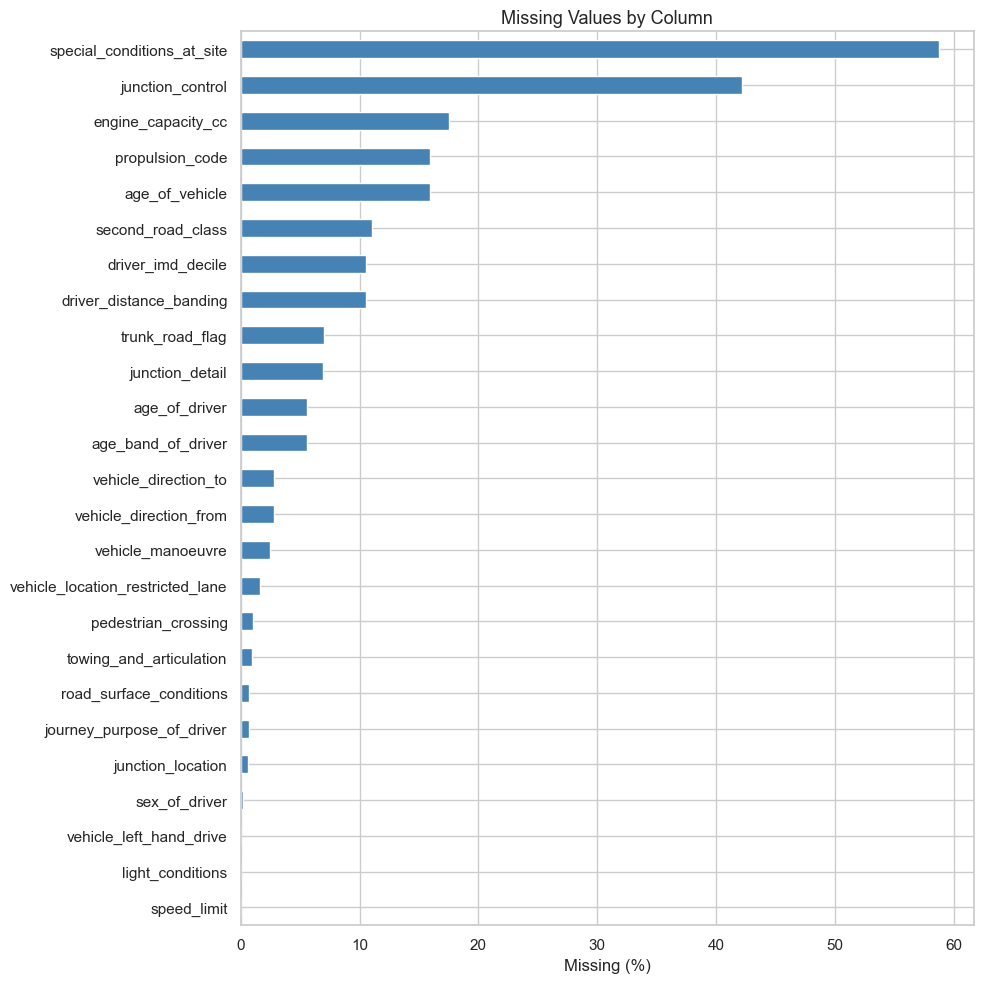

In [18]:
# Visualise missingness
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH + 'missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values found.')

#### 2.6c Decision: Drop High-Missingness Columns

`special_conditions_at_site` has over 58% missing values, making it unsuitable for modelling. This may add more noise to the model and shall be dropped.


Shape after dropping high-missingness columns: (100927, 35)


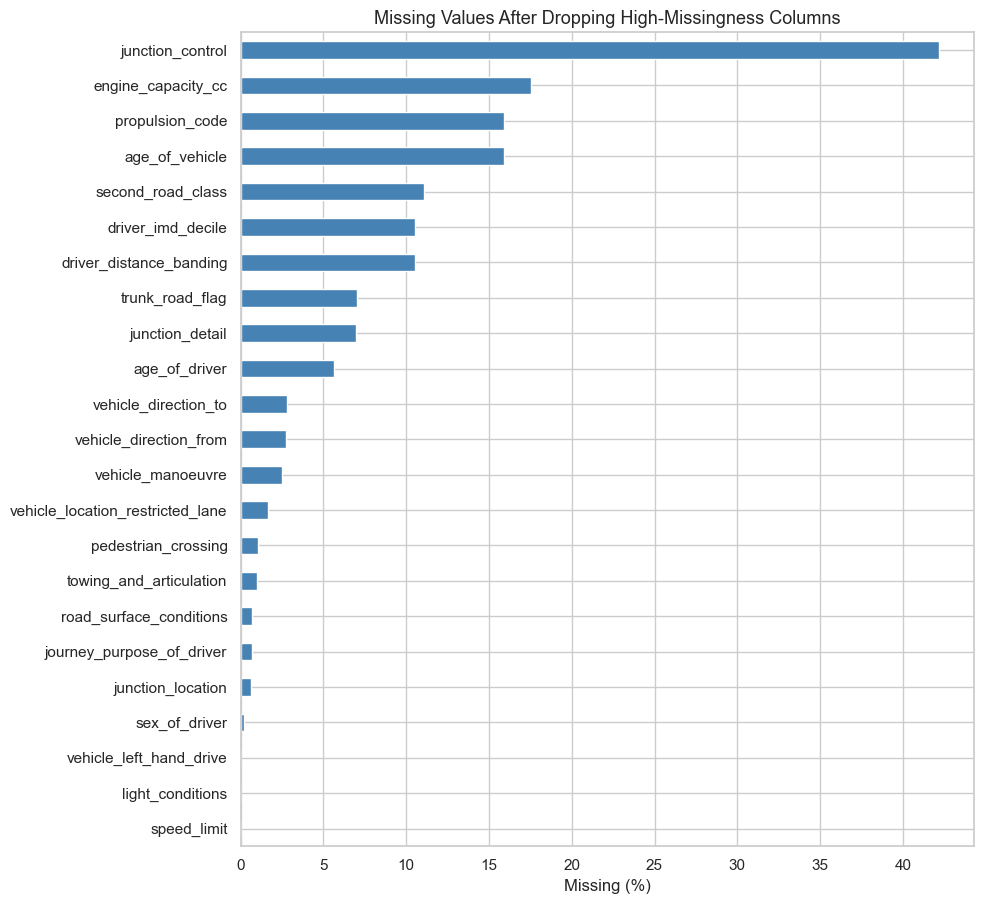

In [19]:
# Drop columns with excessive missingness
df = df.drop(columns=['special_conditions_at_site'], errors='ignore')
df = df.drop(columns=['age_band_of_driver'], errors='ignore')
print(f'Shape after dropping high-missingness columns: {df.shape}')

# Recompute missingness on the cleaned df
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

# Visualise updated missingness
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    missing_df['missing_pct'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values After Dropping High-Missingness Columns')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')


Even after removing special_conditions_at_site there is still a large discrepancy with junction_control having a large amount of missing data relative to other columns. However, junction_control being missing also means that a collision did not happen at a junction which does provide information. 

Instead, this will be kept but imputed missing as "Not a junction".

In [20]:
df['junction_control'] = df['junction_control'].fillna('Not at junction')  # or a specific "None" category

### 2.7 Class Imbalance

To visualise the class imbalance, a simple bar chart is amde to show how many accidents are slight (Category 0) vs. how many were serious or fatal (Category 1). 

This is done to train the model on how to predict something by learning through example. However, if most of the examples are category 0 and a small amount are category 1, then the model will only try to guess category 0 most of the time. This creates a class imbalance and the chart below will visualise this. 

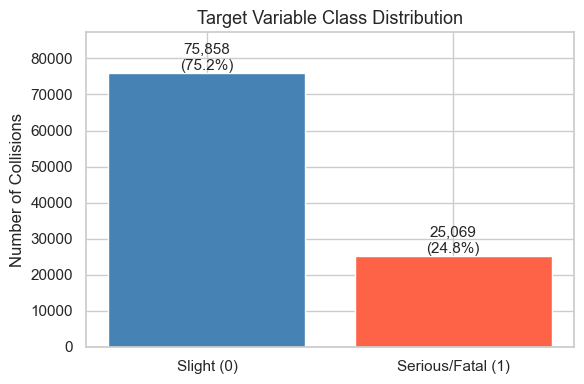

In [21]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Slight (0)', 'Serious/Fatal (1)']
counts = df['target'].value_counts().sort_index()
bars = ax.bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='white')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Target Variable Class Distribution')
ax.set_ylabel('Number of Collisions')
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig(PLOTS_PATH + 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart above shows how a majority of collisions are category 0 while a minority are category 1. This is why AUC ROC is chosen as it will help measure how well the model identifies the rarer category 1 cases without being affected by the larger number of category 0 types.

### 2.8 Feature Distributions

Feauture distributions will help create a translation dictionary for the categories in the datset. Because variables such as weather or day of the week are measured in binary numbers, this dictionary alllows for the binary variables to be translated so they are human readable. This makes it easier for us to understand the data when creating visualisations. 

In [22]:
# ── STATS19 Label Mappings ─────────────────────────────────────────────────
LABEL_MAPS = {
    'day_of_week': {
        1: 'Sunday', 2: 'Monday', 3: 'Tuesday', 4: 'Wednesday',
        5: 'Thursday', 6: 'Friday', 7: 'Saturday'
    },
    'light_conditions': {
        1: 'Daylight',
        4: 'Dark – lights lit',
        5: 'Dark – lights unlit',
        6: 'Dark – no lighting',
        7: 'Dark – lighting unknown'
    },
    'weather_conditions': {
        1: 'Fine', 2: 'Raining', 3: 'Snowing',
        4: 'Fine + high winds', 5: 'Raining + high winds',
        6: 'Snowing + high winds', 7: 'Fog/Mist',
        8: 'Other', 9: 'Unknown'
    },
    'road_surface_conditions': {
        1: 'Dry', 2: 'Wet/Damp', 3: 'Snow',
        4: 'Frost/Ice', 5: 'Flood', 6: 'Oil/Diesel', 7: 'Mud'
    },
    'road_type': {
        1: 'Roundabout', 2: 'One-way street', 3: 'Dual carriageway',
        6: 'Single carriageway', 7: 'Slip road', 9: 'Unknown', 12: 'Slip road/One-way'
    },
    'urban_or_rural_area': {
        1: 'Urban', 2: 'Rural'
    },
    'junction_detail': {
        0: 'Not at junction', 13: 'T or staggered junction', 16: 'Crossroads',
        17: 'Multi-way junction', 18: 'Private drive or entrance', 99: 'Unknown'
    },
    'junction_control': {
        0: 'Not at junction', 1: 'Authorised person', 2: 'Auto traffic signal',
        3: 'Stop sign', 4: 'Give way/Uncontrolled'
    }
}


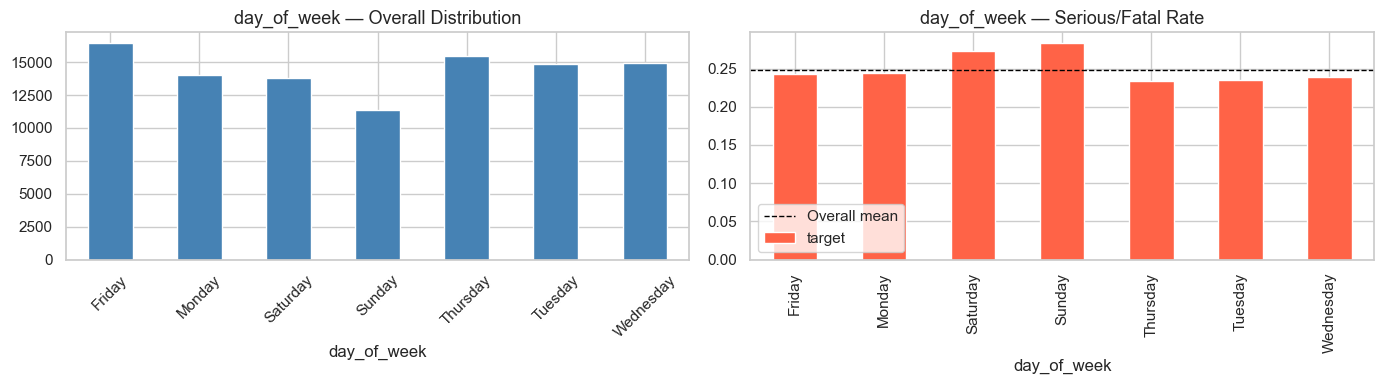

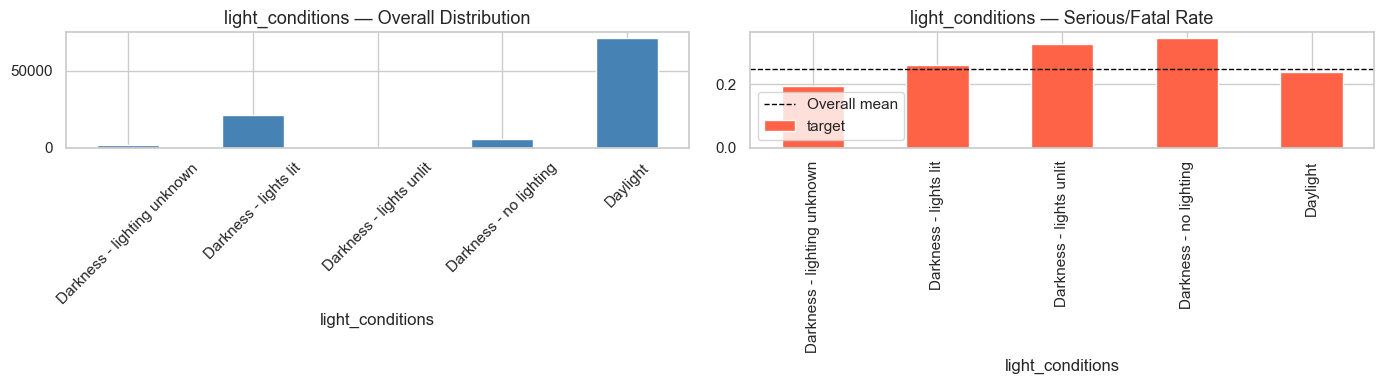

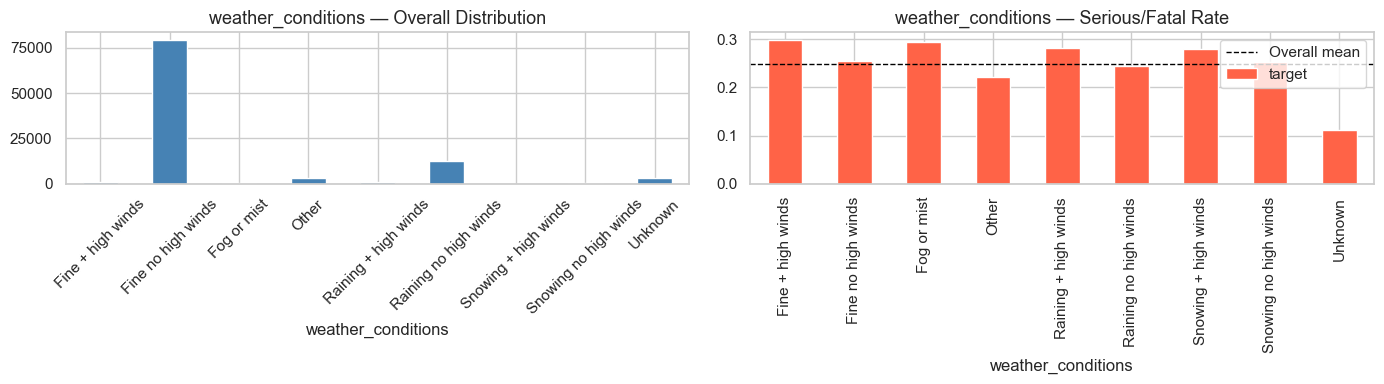

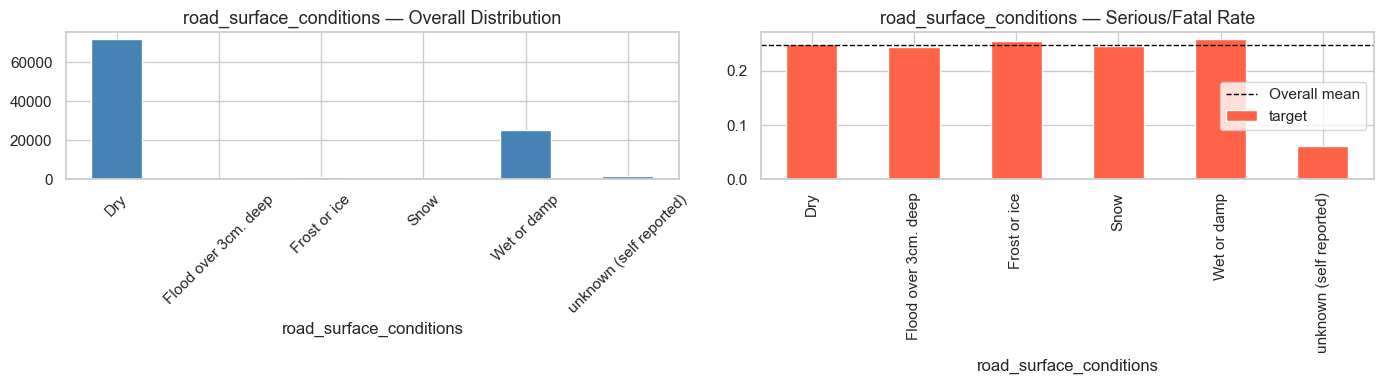

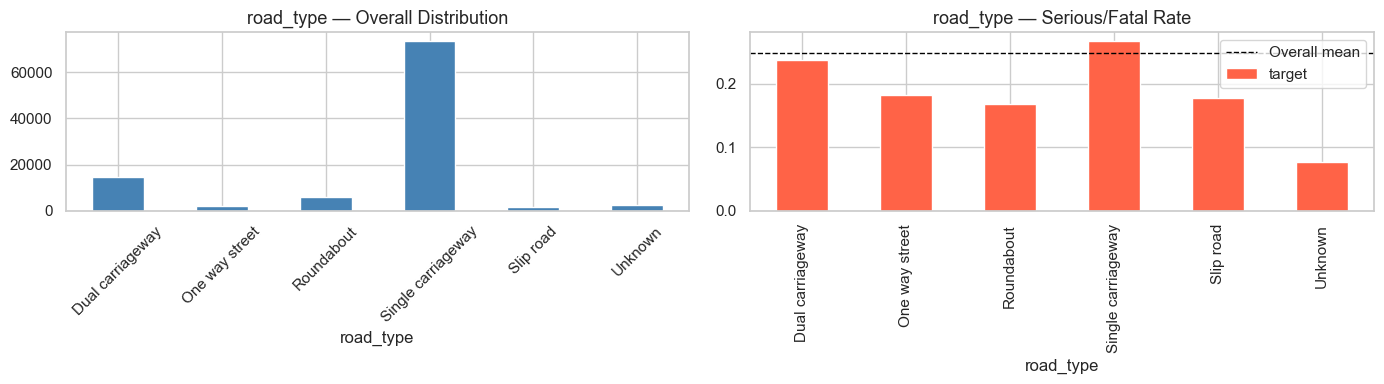

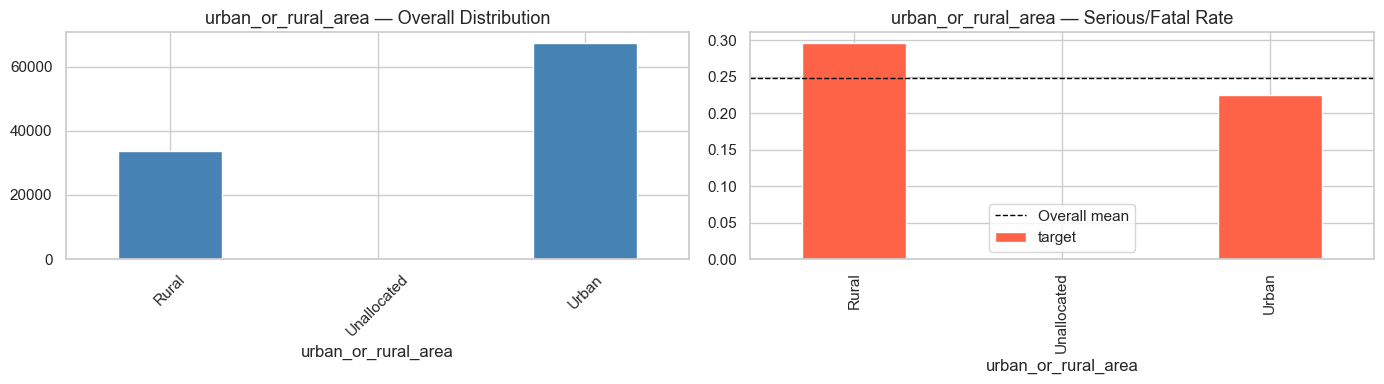

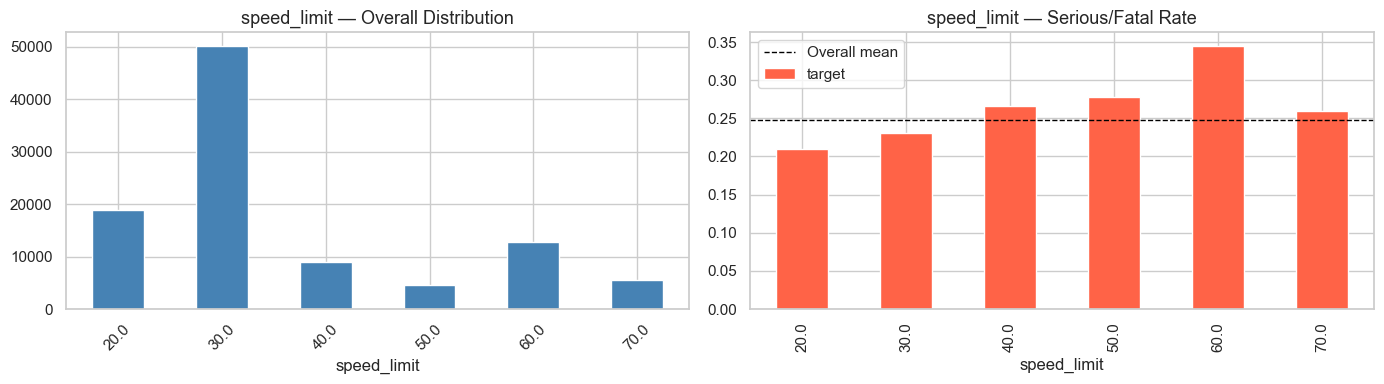

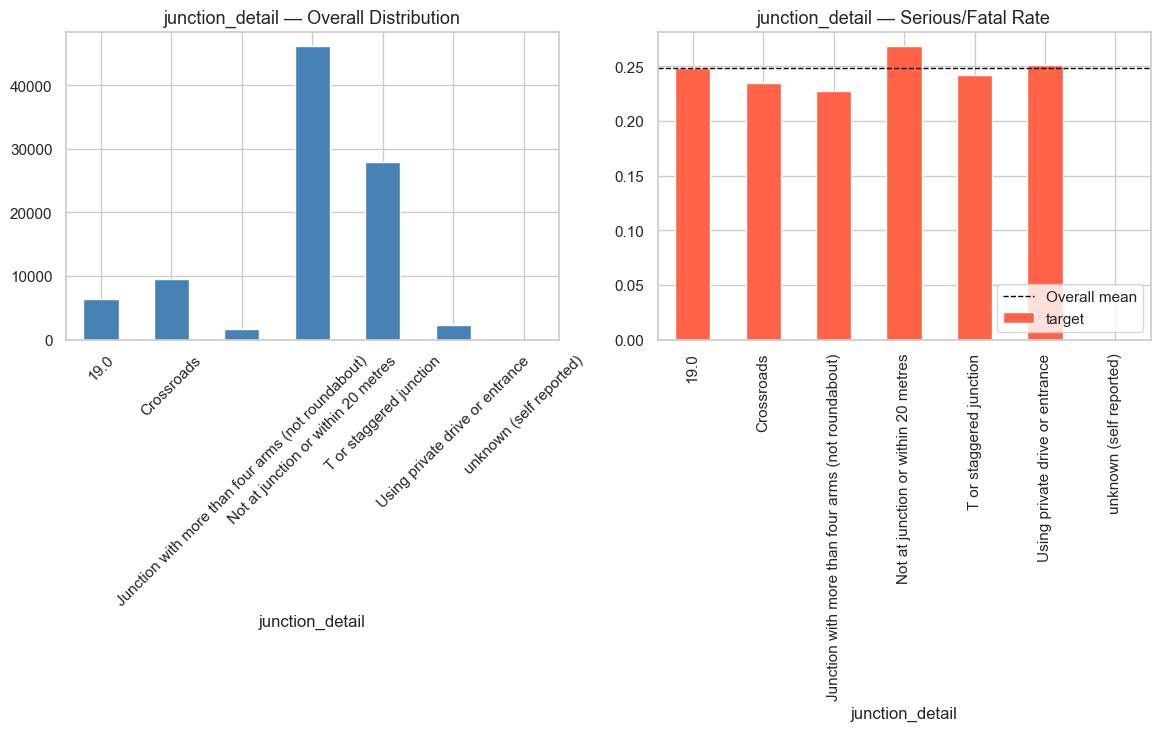

In [23]:
# Key categorical features to explore
categorical_features = [
    'day_of_week', 'light_conditions', 'weather_conditions',
    'road_surface_conditions', 'road_type', 'urban_or_rural_area',
    'speed_limit', 'junction_detail'
]

for feat in categorical_features:
    if feat not in df.columns:
        continue

    plot_series = df[feat]
    plot_series_clean = plot_series.dropna().astype(str)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_series_clean.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title(f'{feat} — Overall Distribution')
    axes[0].tick_params(axis='x', rotation=45)

    rate = df.groupby(plot_series_clean)['target'].mean().sort_index()
    rate.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
    axes[1].set_title(f'{feat} — Serious/Fatal Rate')
    axes[1].axhline(df['target'].mean(), color='black', linestyle='--', linewidth=1, label='Overall mean')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


### 2.9 Numeric Feature Distributions

Many columns in this dataset are stored as integers but are actually **categorical variables** 
encoded as numbers (e.g. `road_type`, `light_conditions`, `day_of_week`). These are handled 
separately as categorical features in section 2.8

The following are genuinely numeric features. These are either continuous or ordinal variables where the magnitude is meaningful:

- `number_of_vehicles` — number of vehicles involved in the collision
- `speed_limit` — posted speed limit at the collision location (mph)
- `age_of_driver` — age of the primary driver (from vehicles file)
- `engine_capacity_cc` — engine size of the primary vehicle
- `age_of_vehicle` — age of the primary vehicle in years
- `driver_imd_decile` — deprivation index of the driver's home area (1=most deprived, 10=least)

Note: `number_of_casualties` was excluded as a leakage risk as the casualty count is only known 
after the accident has been fully assessed, which is the same point at which severity is 
recorded. Including it would allow the model to "cheat" using post-event information

Note: `longitude` and `latitude` are excluded from distributional plots as they represent 
geographic coordinates rather than predictive features in the traditional sense

Plotting 6 numeric features: ['number_of_vehicles', 'speed_limit', 'age_of_driver', 'engine_capacity_cc', 'age_of_vehicle', 'driver_imd_decile']


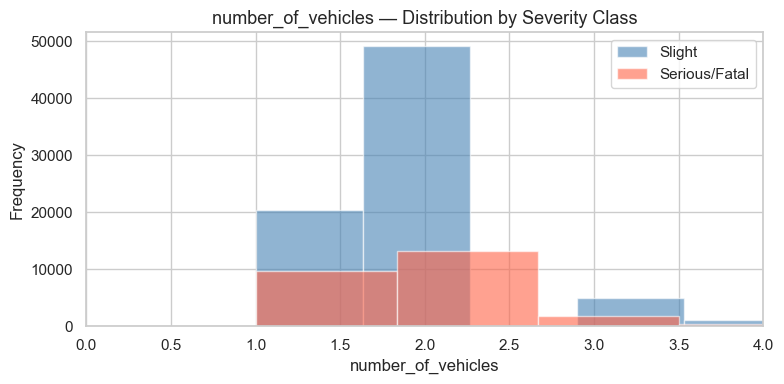

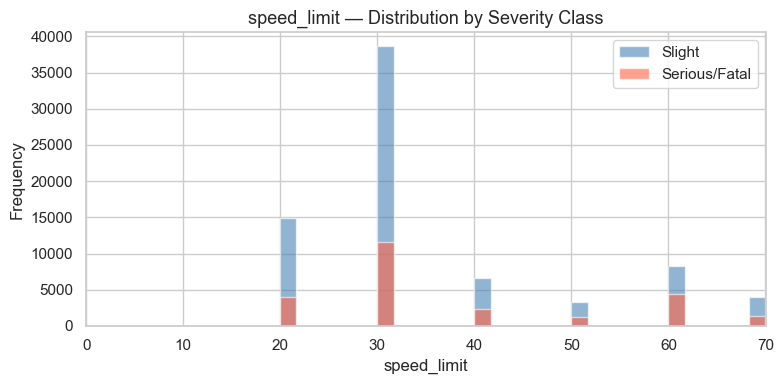

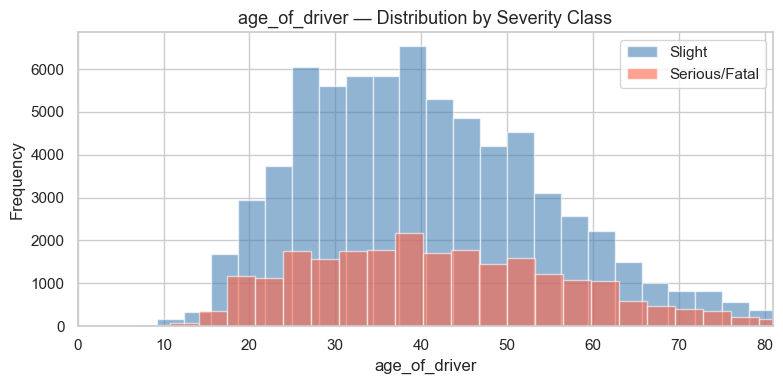

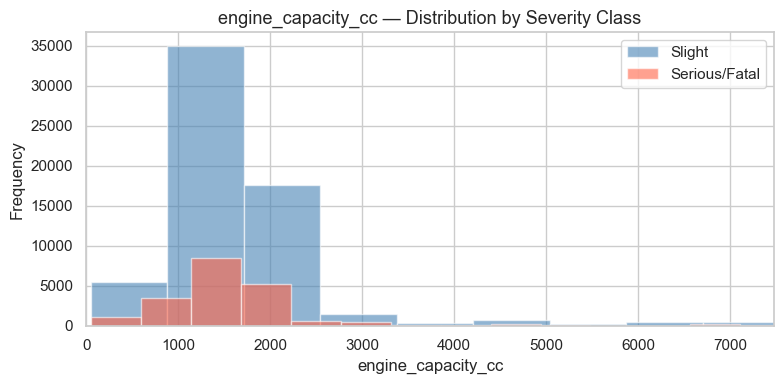

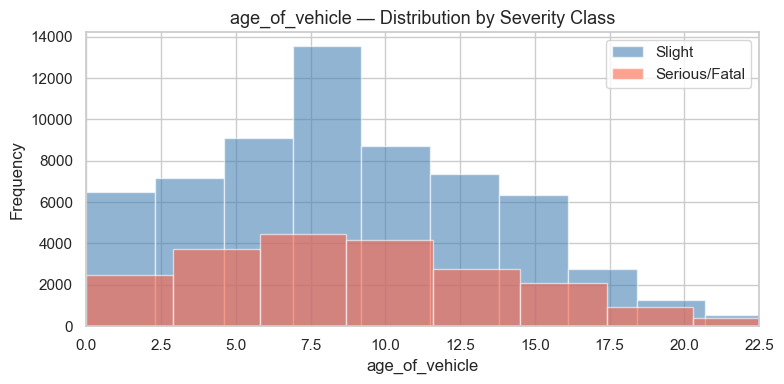

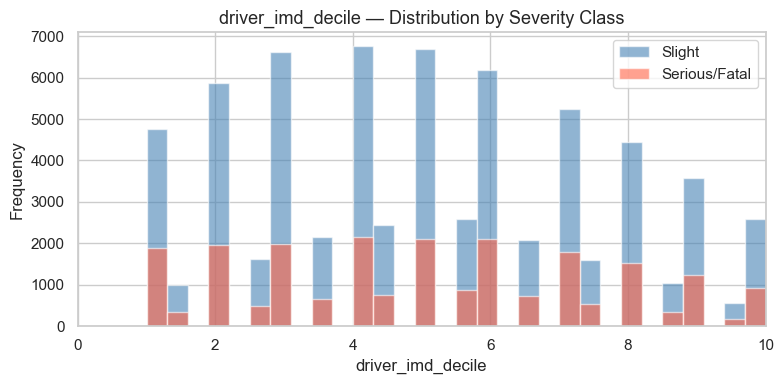

In [24]:
truly_numeric = [
    'number_of_vehicles',
    'speed_limit',
    'age_of_driver',
    'engine_capacity_cc',
    'age_of_vehicle',
    'driver_imd_decile',
]

# Only plot features that exist in the dataset
truly_numeric = [f for f in truly_numeric if f in df.columns]
print(f'Plotting {len(truly_numeric)} numeric features: {truly_numeric}')

for feat in truly_numeric:
    fig, ax = plt.subplots(figsize=(8, 4))
    df[df['target']==0][feat].dropna().plot(
        kind='hist', bins=30, ax=ax, alpha=0.6, color='steelblue', label='Slight')
    df[df['target']==1][feat].dropna().plot(
        kind='hist', bins=30, ax=ax, alpha=0.6, color='tomato', label='Serious/Fatal')
    # Auto-cap x-axis at 99th percentile to remove outlier distortion
    upper = df[feat].quantile(0.99)
    ax.set_xlim(left=0, right=upper)
    ax.set_title(f'{feat} — Distribution by Severity Class')
    ax.set_xlabel(feat)
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_PATH + f'dist_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 2.10 Correlation Heatmap (Numeric Features)

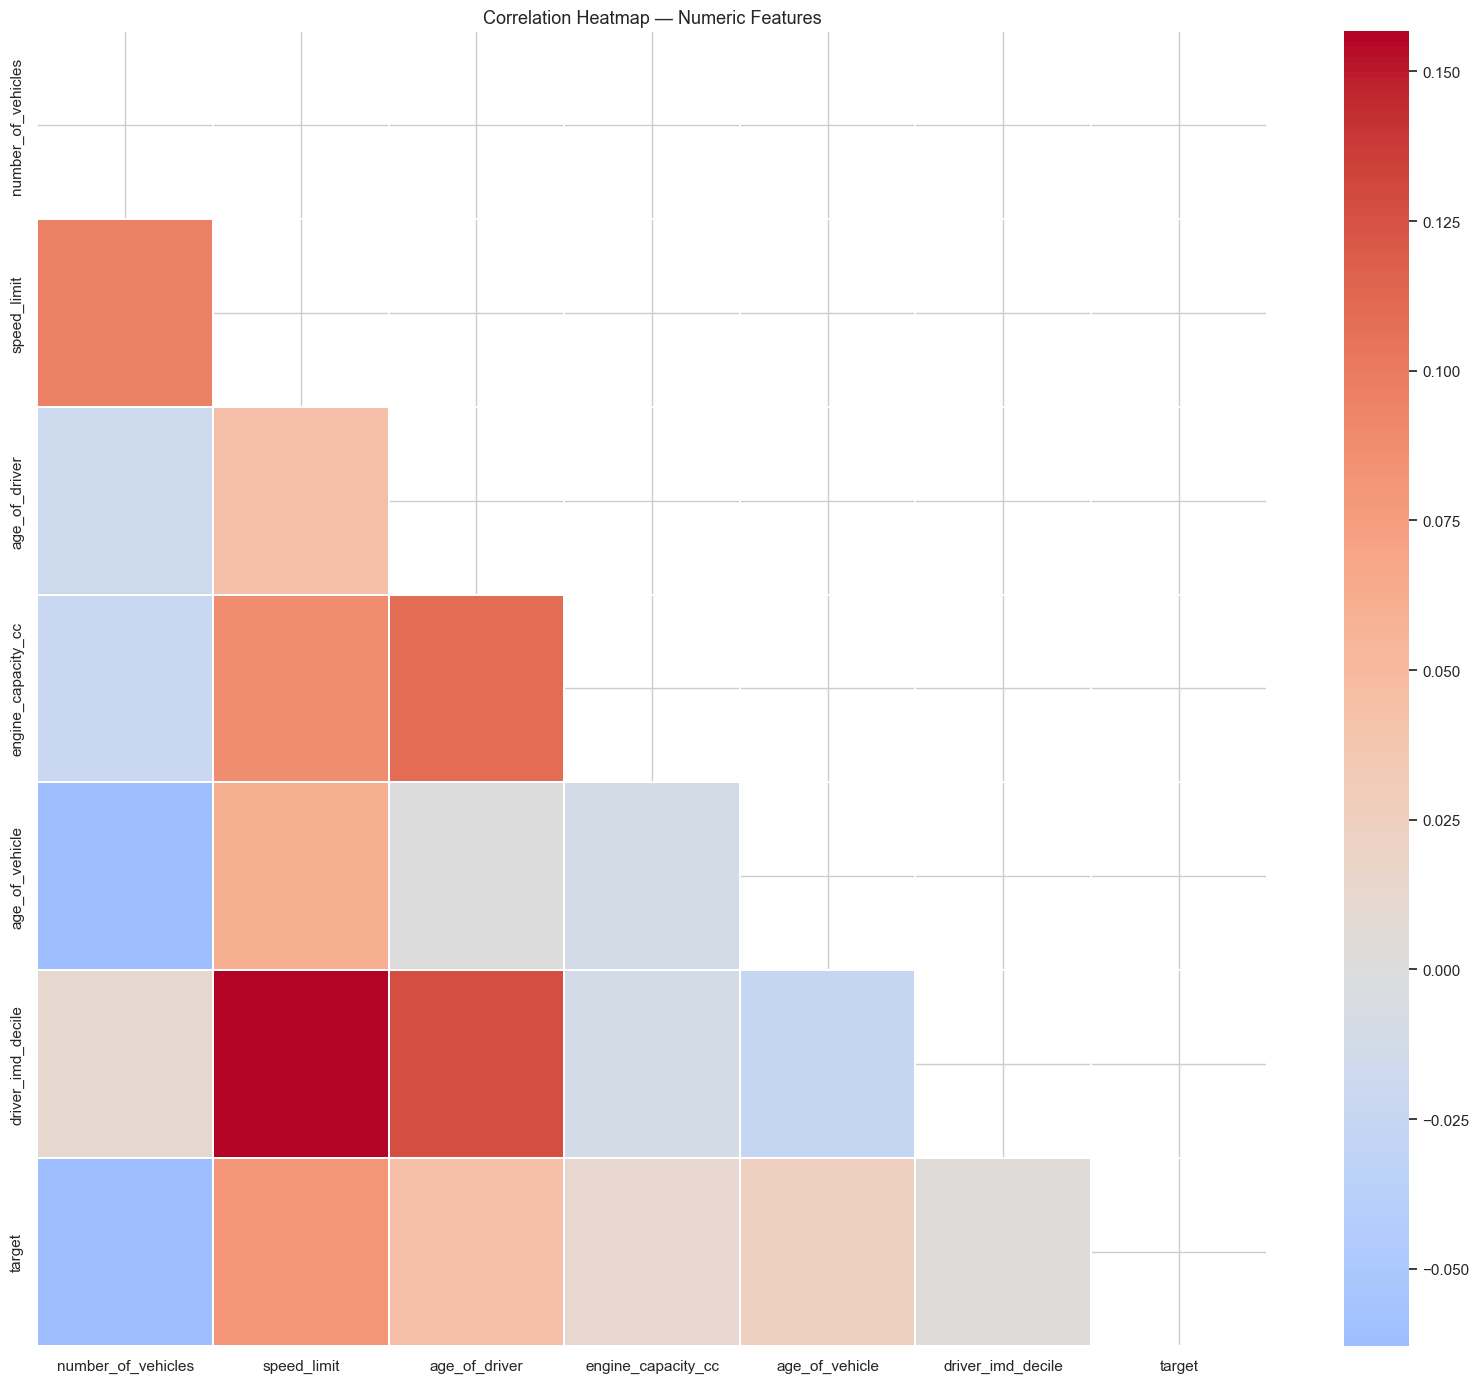

In [25]:
numeric_df = df[truly_numeric + ['target']].copy()

if len(truly_numeric) > 1:
    fig, ax = plt.subplots(figsize=(16, 14))
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
                center=0, ax=ax, linewidths=0.3)
    ax.set_title('Correlation Heatmap — Numeric Features')
    plt.tight_layout()
    plt.savefig(PLOTS_PATH + 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Not enough numeric features for a correlation heatmap.')


### 2.11 EDA Summary and Data Quality Notes

- **Rows / Features after join:** [100,927] rows, [43] features (excluding target)
- **Missing values:** `special_conditions_at_site` had the highest missingness (~59%) and was dropped. `junction_control` showed elevated but structurally explainable missingness (collisions not at junctions), retained with NaN. Remaining features had low or zero missingness.
- **age_band_of_driver** is a binned version of `age_of_driver` as keeping both would be redundant. The raw `age_of_driver` is retained as it contains more information
- **Class balance:** ~75% Slight (0) vs. ~25% Serious/Fatal (1). This shows a moderate imbalance that will require attention during modelling (e.g. class weighting or SMOTE).
- **Key patterns observed:**
  - Rural collisions show a markedly higher serious/fatal rate than urban collisions.
  - Higher speed limits are strongly associated with increased severity.
  - Dark unlit road conditions correlate with higher severity despite lower frequency.
  - Most collisions occur on single carriageways and in fine weather (high frequency, moderate risk).
- **Data quality issues:**
  - STATS19 encodes missing values as `-1` (sentinel); replaced with `NaN` across all columns.
  - `special_conditions_at_site` dropped due to ~59% missingness.
  - `urban_or_rural_area` category 3 ("Unallocated") has zero records in 2024 data. This will be treated as NaN.
- **Leakage risks identified:** Adjusted severity columns (`enhanced_severity_collision`, `collision_injury_based`, `collision_adjusted_severity_serious/slight`) were dropped before modelling as they are derived from the target variable.
- **Modelling pitfalls:** Class imbalance (around a 3:1 ratio) may bias models toward predicting the majority class (Slight). AUC-ROC will be used as the primary metric to account for this.


In [26]:
print(df.columns.tolist())
print(df.shape)

['number_of_vehicles', 'date', 'day_of_week', 'time', 'first_road_class', 'road_type', 'speed_limit', 'junction_detail', 'junction_control', 'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'trunk_road_flag', 'age_of_driver', 'engine_capacity_cc', 'age_of_vehicle', 'driver_imd_decile', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'vehicle_left_hand_drive', 'journey_purpose_of_driver', 'sex_of_driver', 'propulsion_code', 'escooter_flag', 'driver_distance_banding', 'target', 'region', 'vehicle_group']
(100927, 35)


---
## Step 3: Data Preparation

---
## Step 3: Prepare the Data

### 3.0 Overview

The following preprocessing steps are applied in order:
1. Extract `hour_of_day` from `time` and `month` from `date`, then drop originals
2. Split into train (80%), validation (10%), and test (10%) sets
3. Impute missing values, this will be median for numeric, mode for categorical and will be fitted on training set only
4. One-hot encode categorical features, this will be fitted on training set only
5. Scale numeric features using StandardScale, this will be fitted on training set only
6. Data validation checks

All preprocessing is fitted on the training set only and applied to validation and test sets to prevent data leakage.

### 3.1 Extracting Date and Time Features

In [27]:

# Extract hour of day from time column
df['hour_of_day'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour

# Extract month from date column
df['month'] = pd.to_datetime(df['date'], errors='coerce').dt.month

# Drop original date and time columns
df = df.drop(columns=['date', 'time'])

print(f'Shape after feature extraction: {df.shape}')
print(f'hour_of_day sample: {df["hour_of_day"].value_counts().sort_index().head()}')
print(f'month sample: {df["month"].value_counts().sort_index()}')

Shape after feature extraction: (100927, 35)
hour_of_day sample: hour_of_day
0    1646
1    1064
2     774
3     642
4     590
Name: count, dtype: int64
month sample: month
1.0     3131
2.0     3337
3.0     3229
4.0     3320
5.0     3392
6.0     3285
7.0     3020
8.0     3205
9.0     3466
10.0    3343
11.0    3370
12.0    3473
Name: count, dtype: int64


### 3.2 Define Feature Types

In [28]:
# Separate target from features
X = df.drop(columns=['target'])
y = df['target']

# Genuinely numeric features (continuous/ordinal which will be scaled)
numeric_features = [
    'number_of_vehicles',
    'speed_limit',
    'age_of_driver',
    'engine_capacity_cc',
    'age_of_vehicle',
    'driver_imd_decile',
    'hour_of_day',
    'month',
]

# Categorical features (will be one-hot encoded)
categorical_features = [col for col in X.columns if col not in numeric_features]

# Replace NaN with the string 'Unknown' before converting to string
# This prevents NaN becoming 'nan' which bypasses the imputer
for col in categorical_features:
    X[col] = X[col].fillna('Unknown').astype(str)

print(f'Numeric features ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numeric features (8): ['number_of_vehicles', 'speed_limit', 'age_of_driver', 'engine_capacity_cc', 'age_of_vehicle', 'driver_imd_decile', 'hour_of_day', 'month']
Categorical features (26): ['day_of_week', 'first_road_class', 'road_type', 'junction_detail', 'junction_control', 'second_road_class', 'pedestrian_crossing', 'light_conditions', 'weather_conditions', 'road_surface_conditions', 'urban_or_rural_area', 'trunk_road_flag', 'towing_and_articulation', 'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to', 'vehicle_location_restricted_lane', 'junction_location', 'vehicle_left_hand_drive', 'journey_purpose_of_driver', 'sex_of_driver', 'propulsion_code', 'escooter_flag', 'driver_distance_banding', 'region', 'vehicle_group']


### 3.3 Train / Validation / Test Split (80/10/10)

In [29]:

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

# Second split: 50/50 of temp = 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

print(f'Train:      {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)')
print()
print('Class balance check:')
print(f'  Train      — serious/fatal: {y_train.mean()*100:.1f}%')
print(f'  Validation — serious/fatal: {y_val.mean()*100:.1f}%')
print(f'  Test       — serious/fatal: {y_test.mean()*100:.1f}%')

Train:      80,741 rows (80.0%)
Validation: 10,093 rows (10.0%)
Test:       10,093 rows (10.0%)

Class balance check:
  Train      — serious/fatal: 24.8%
  Validation — serious/fatal: 24.8%
  Test       — serious/fatal: 24.8%


### 3.4 Build Preprocessing Pipeline

In [30]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric pipeline: impute with median, then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

# Fit on training set only, transform all three splits
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed   = preprocessor.transform(X_val)
X_test_processed  = preprocessor.transform(X_test)

print(f'Processed train shape:      {X_train_processed.shape}')
print(f'Processed validation shape: {X_val_processed.shape}')
print(f'Processed test shape:       {X_test_processed.shape}')

Processed train shape:      (80741, 204)
Processed validation shape: (10093, 204)
Processed test shape:       (10093, 204)


### 3.5 Data Validation Checks

In [31]:
import numpy as np

print('=== DATA VALIDATION CHECKS ===')
print()

# Check 1: No missing values in processed data
train_missing = np.isnan(X_train_processed).sum()
val_missing   = np.isnan(X_val_processed).sum()
test_missing  = np.isnan(X_test_processed).sum()
print(f'Missing values — Train: {train_missing}, Val: {val_missing}, Test: {test_missing}')
assert train_missing == 0, 'Missing values found in training set!'
assert val_missing == 0,   'Missing values found in validation set!'
assert test_missing == 0,  'Missing values found in test set!'
print('PASS: No missing values')
print()

# Check 2: Shapes are consistent
assert X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1], \
    'Feature count mismatch between splits!'
print(f'PASS: All splits have {X_train_processed.shape[1]} features')
print()

# Check 3: Class balance preserved across splits
for name, y_split in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    rate = y_split.mean() * 100
    assert 20 < rate < 30, f'Class balance looks wrong in {name}: {rate:.1f}%'
    print(f'PASS: {name} class balance — {rate:.1f}% serious/fatal')
print()

# Check 4: No overlap between splits
train_idx = set(X_train.index)
val_idx   = set(X_val.index)
test_idx  = set(X_test.index)
assert len(train_idx & val_idx) == 0,  'Overlap between train and validation!'
assert len(train_idx & test_idx) == 0, 'Overlap between train and test!'
assert len(val_idx & test_idx) == 0,   'Overlap between validation and test!'
print('PASS: No overlap between splits')

=== DATA VALIDATION CHECKS ===

Missing values — Train: 0, Val: 0, Test: 0
PASS: No missing values

PASS: All splits have 204 features

PASS: Train class balance — 24.8% serious/fatal
PASS: Validation class balance — 24.8% serious/fatal
PASS: Test class balance — 24.8% serious/fatal

PASS: No overlap between splits



### 3.6 Step 3 Summary

- Extracted `hour_of_day` from `time` and `month` from `date`
- Split data 80/10/10 into train/validation/test with stratification to preserve class balance
- Created a sklearn Pipeline: median imputation + StandardScaler for numeric features, mode imputation + OneHotEncoder for categorical features
- All preprocessing fitted on training set only so there is no leakage into validation or test sets
- All validation checks passed: no missing values, consistent shapes, no index overlap between splits

---
## Step 4: Explore Different Models and Shortlist the Best

### 4.1 Logistic Regression (Baseline)

This serves as the interpretable baseline for this project. Logistic Regression provides a good performance floor and its coefficients offer direct insight into feature-outcome relationships. It models the log-odds of serious/fatal injury as a linear combination of input features, with class_weight='balanced' applied to account for the 80:20 class imbalance. However, it cannot capture non-linear interactions between features (e.g., the combined effect of high speed limits on rural roads). This model trains in under a second and produces well-calibrated probabilities, making it a reliable reference point against which more complex models are compared.


In [32]:
# Imports 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import time

# Dictionary to store all results for final comparison
all_results = {}

#### 4.1a Training

In [ ]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_SEED
)

start = time.time()
lr.fit(X_train_processed, y_train)
lr_time = round(time.time() - start, 1)

y_pred_lr = lr.predict(X_val_processed)
y_prob_lr = lr.predict_proba(X_val_processed)[:, 1]

lr_auc = roc_auc_score(y_val, y_prob_lr)
lr_f1  = f1_score(y_val, y_pred_lr)
lr_pre = precision_score(y_val, y_pred_lr)
lr_rec = recall_score(y_val, y_pred_lr)

print(f'AUC-ROC:   {lr_auc:.4f}')
print(f'F1:        {lr_f1:.4f}')
print(f'Precision: {lr_pre:.4f}')
print(f'Recall:    {lr_rec:.4f}')
print(f'Train time: {lr_time}s')

all_results['Logistic Regression'] = {
    'AUC-ROC': round(lr_auc, 4), 'F1': round(lr_f1, 4),
    'Precision': round(lr_pre, 4), 'Recall': round(lr_rec, 4),
    'Train time (s)': lr_time
}

AUC-ROC:   0.6815
F1:        0.4551
Precision: 0.3492
Recall:    0.6534
Train time: 1.0s


#### 4.1b Confusion Matrix

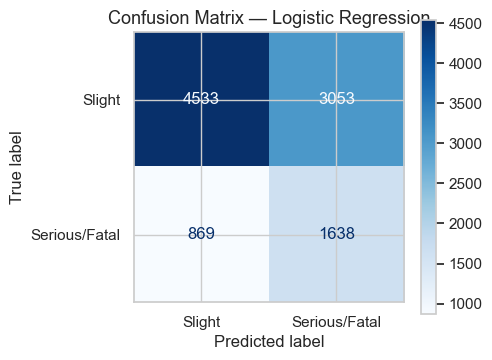

In [34]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_lr,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_lr.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.1c ROC Curve

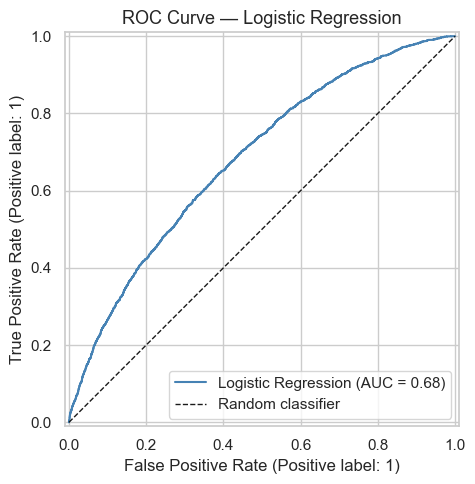

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_lr,
    name='Logistic Regression',
    color='steelblue', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.tight_layout()
plt.savefig('roc_lr.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.1d Top Feature Coefficients

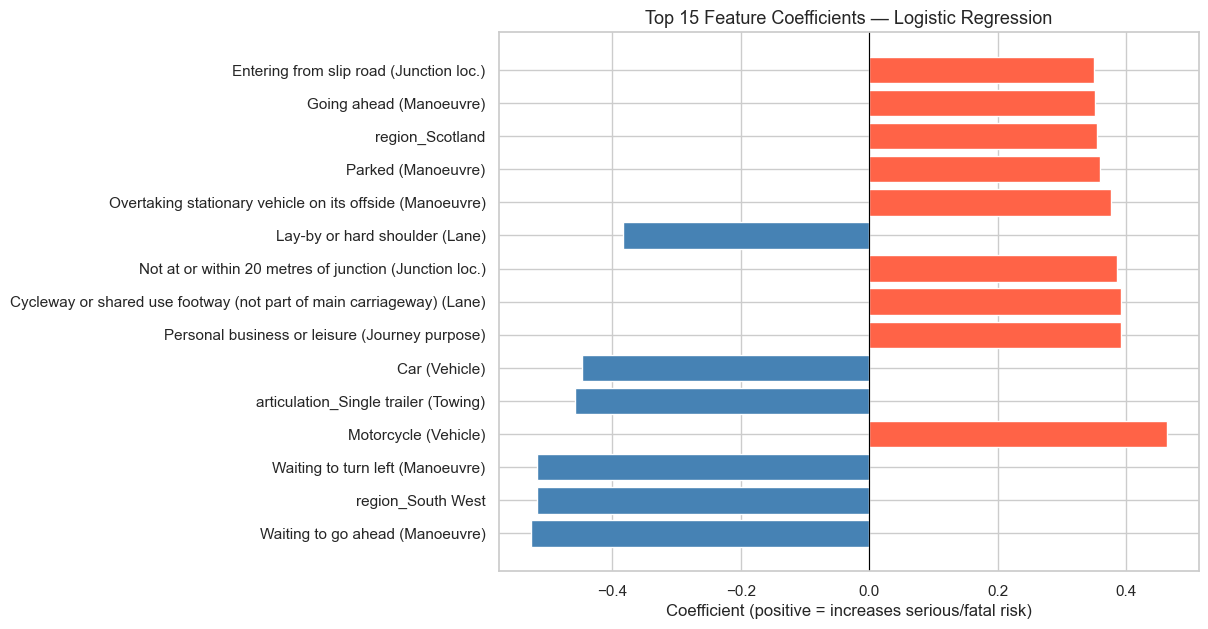

In [36]:
# Get feature names after one-hot encoding
ohe_feature_names = preprocessor.named_transformers_['categorical']['encoder']\
    .get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + ohe_feature_names

coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': lr.coef_[0]
})

# Remove Unknown and self-reported categories — not interpretable
coef_df = coef_df[~coef_df['feature'].str.contains('Unknown|unknown|self report', na=False)]
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)

# Clean labels — remove column prefix
def clean_label(feature):
    # Handle special cases with more than 2 prefix words
    special_prefixes = {
        'vehicle_location_restricted_lane': 'Lane',
        'journey_purpose_of_driver': 'Journey purpose',
        'vehicle_direction_from': 'Direction from',
        'vehicle_direction_to': 'Direction to',
        'vehicle_left_hand_drive': 'LHD',
    }
    
    # Check special prefixes first
    for prefix, label in special_prefixes.items():
        if feature.startswith(prefix + '_'):
            value = feature[len(prefix) + 1:]
            return f'{value} ({label})'
    
    # Standard two-word prefix handling
    parts = feature.split('_', 2)
    if len(parts) >= 3:
        prefix = '_'.join(parts[:2])
        value = parts[2]
        readable_prefix = {
            'vehicle_group': 'Vehicle',
            'vehicle_manoeuvre': 'Manoeuvre',
            'junction_location': 'Junction loc.',
            'junction_control': 'Junction ctrl.',
            'towing_and': 'Towing',
            'road_type': 'Road type',
            'light_conditions': 'Lighting',
            'weather_conditions': 'Weather',
            'road_surface': 'Road surface',
            'urban_or': 'Area',
            'trunk_road': 'Trunk road',
            'propulsion_code': 'Propulsion',
            'sex_of': 'sex_of',
            'hour_of': 'hour_of',
            'age_of': 'age_of',
            'number_of': 'number_of',
        }.get(prefix, prefix)
        return f'{value} ({readable_prefix})'
    return feature

coef_df['feature_short'] = coef_df['feature'].apply(clean_label)

top_coef = coef_df.head(15)
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in top_coef['coefficient']]
ax.barh(top_coef['feature_short'], top_coef['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Feature Coefficients — Logistic Regression')
ax.set_xlabel('Coefficient (positive = increases serious/fatal risk)')
plt.subplots_adjust(left=0.4)
plt.savefig('coef_lr.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.1 Observations — Logistic Regression

- **AUC-ROC: 0.6815** — below the 0.75 target, this is expected for a linear baseline that 
  assumes a linear decision boundary between slight and serious/fatal collisions
- **Confusion matrix:** Catches 65% of serious/fatal cases (recall 0.6534) but low 
  precision (0.3492). So when it predicts serious/fatal it is only correct 35% of the 
  time, reflecting the difficulty of the classification task
- **Key features:** Motorcycle involvement and cycleway location increase serious/fatal 
  risk; car involvement and waiting manoeuvres reduce it
- **Limitations observed:** Linear decision boundary cannot capture complex interactions 
  between road conditions, vehicle type, and driver behaviour


### 4.2 Decision Tree

A Decision Tree splits the data based on feature thresholds to create a set of 
decision rules. Unlike Logistic Regression, this model can capture non-linear relationships and 
interactions between features without any assumptions about the data distribution.

**Strengths:**
- Naturally handles both numeric and categorical features
- Highly interpretable. Tree structure can be visualised and explained
- No assumption of linearity — can capture complex road condition interactions

**Weaknesses:**
- Prone to overfitting as deep tree memorises training data rather than generalising
- Instability as small changes in data can produce very different trees
- Generally weaker than ensemble methods (Random Forest, XGBoost)

 `max_depth=10` is used to limit overfitting while still allowing the tree to learn meaningful patterns.

#### 4.2a Training the Decision Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=10,
    random_state=RANDOM_SEED
)

start = time.time()
dt.fit(X_train_processed, y_train)
dt_time = round(time.time() - start, 1)

y_pred_dt = dt.predict(X_val_processed)
y_prob_dt = dt.predict_proba(X_val_processed)[:, 1]

dt_auc = roc_auc_score(y_val, y_prob_dt)
dt_f1  = f1_score(y_val, y_pred_dt)
dt_pre = precision_score(y_val, y_pred_dt)
dt_rec = recall_score(y_val, y_pred_dt)

print(f'AUC-ROC:   {dt_auc:.4f}')
print(f'F1:        {dt_f1:.4f}')
print(f'Precision: {dt_pre:.4f}')
print(f'Recall:    {dt_rec:.4f}')
print(f'Train time: {dt_time}s')

all_results['Decision Tree'] = {
    'AUC-ROC': round(dt_auc, 4), 'F1': round(dt_f1, 4),
    'Precision': round(dt_pre, 4), 'Recall': round(dt_rec, 4),
    'Train time (s)': dt_time
}

AUC-ROC:   0.6627
F1:        0.4457
Precision: 0.3307
Recall:    0.6833
Train time: 0.6s


#### 4.2b Confusion Matrix

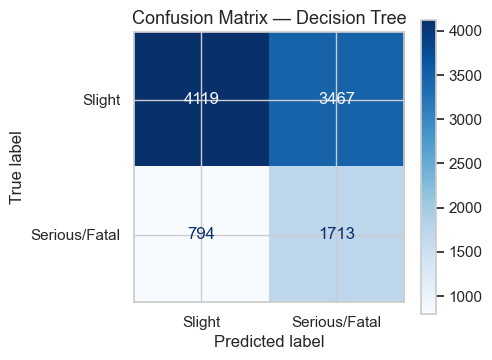

In [38]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_dt,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.savefig('confusion_dt.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.2c ROC Curve

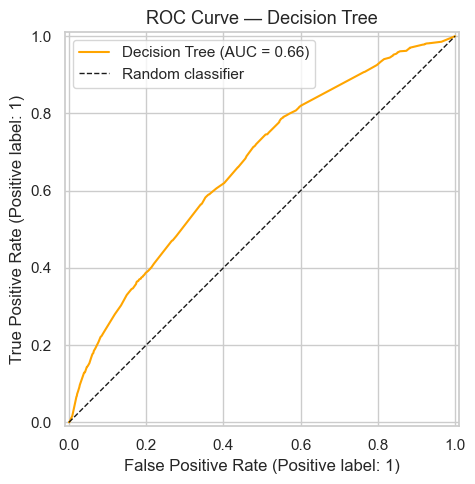

In [39]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_dt,
    name='Decision Tree',
    color='orange', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curve — Decision Tree')
ax.legend()
plt.tight_layout()
plt.savefig('roc_dt.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.2d Top Feature Coefficients

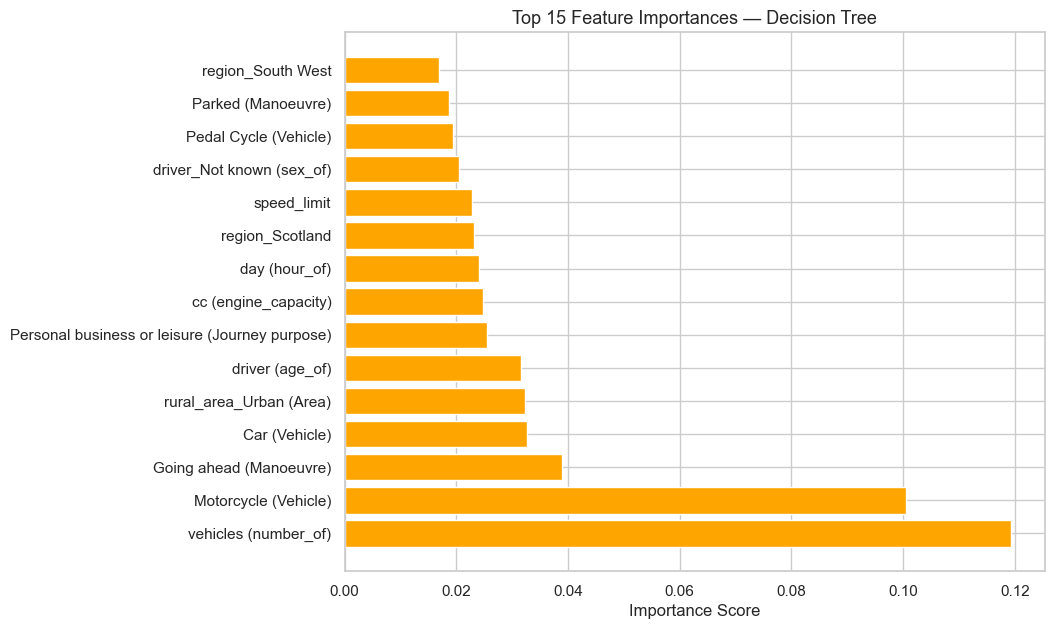

In [40]:
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': dt.feature_importances_
})

# Remove Unknown and self-reported categories
importance_df = importance_df[~importance_df['feature'].str.contains('Unknown|unknown|self report', na=False)]
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df['feature_short'] = importance_df['feature'].apply(clean_label)

top_imp = importance_df.head(15)
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top_imp['feature_short'], top_imp['importance'], color='orange', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Decision Tree')
ax.set_xlabel('Importance Score')
plt.subplots_adjust(left=0.4)
plt.savefig('importance_dt.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.2e Visualisation of the Deceision Tree

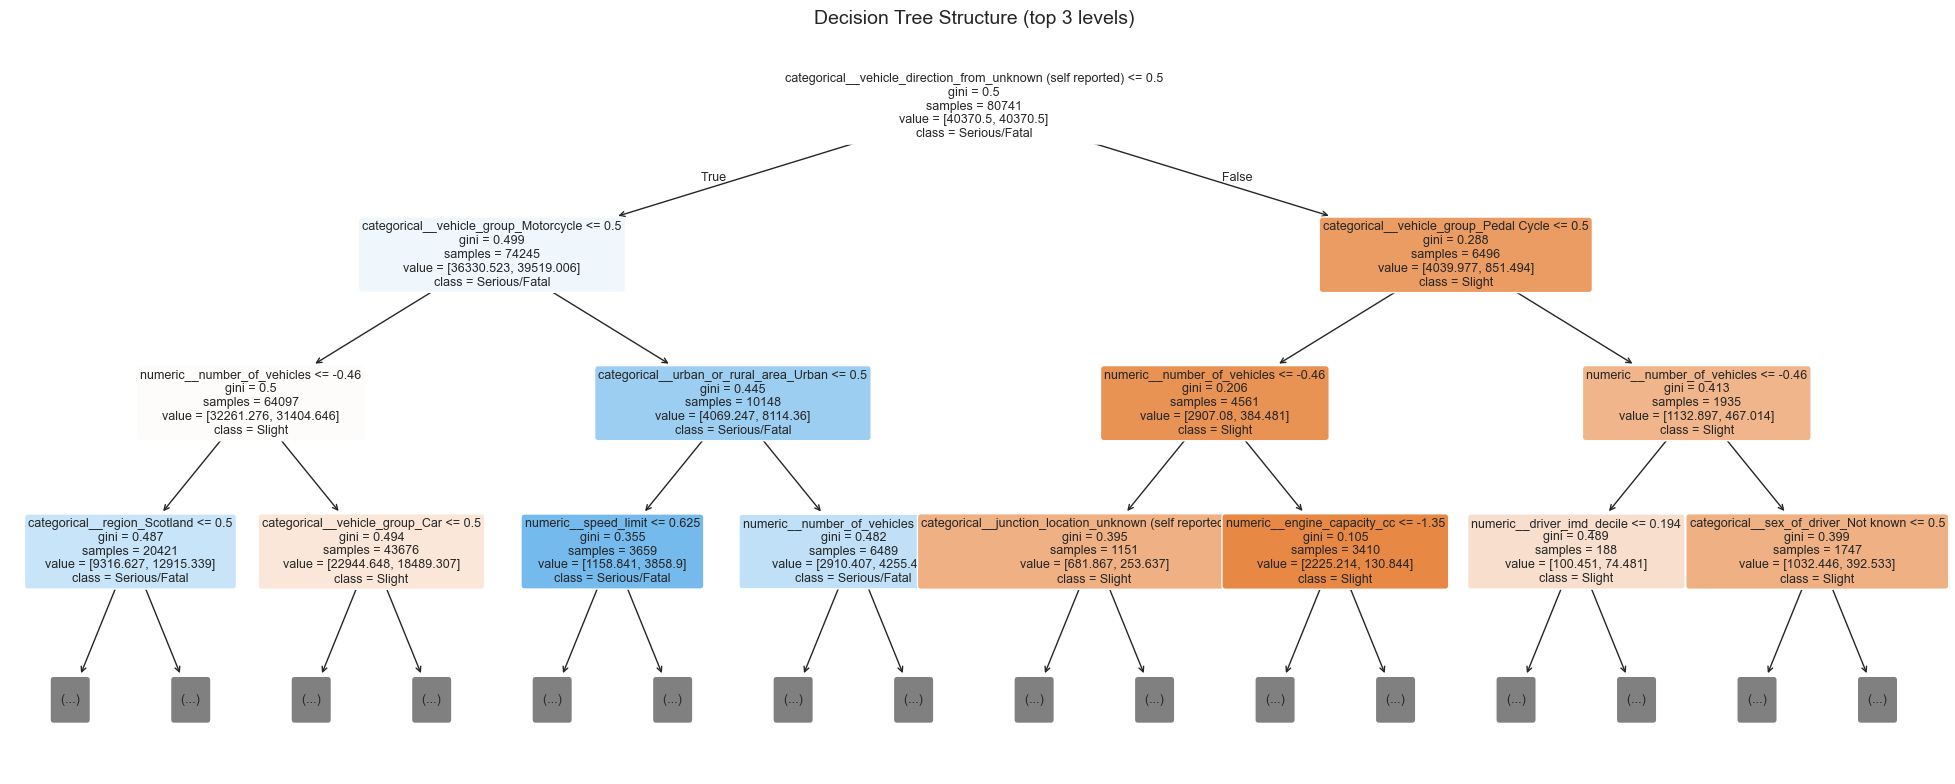

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=feature_names,
          class_names=['Slight', 'Serious/Fatal'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title("Decision Tree Structure (top 3 levels)", fontsize=14)
plt.tight_layout()
plt.show()

#### 4.2 Observations — Decision Tree
- **AUC-ROC: 0.6627** — below the Logistic Regression baseline of 0.6815, suggesting 
  a single tree struggles to generalise despite its non-linear capability
- **Confusion matrix:** Highest recall of all models so far (68.3%) but lowest 
  precision (33.1%). The model casts a wide net, catching more serious/fatal cases 
  but ends up creating many false alarms
- **Key features:** Number of vehicles and motorcycle involvement dominate the splits, 
  consistent with the strong signal in the Logistic Regression coefficients
- **Limitations observed:** A single decision tree is prone to overfitting and 
  instability. This means small changes in training data can produce very different trees. Ensemble methods (Random Forest, XGBoost, LightGBM) that aggregate 
  many trees may improve generalisation

### 4.3 Random Forest

Random Forest is an ensemble method that builds many decision trees on random subsets of 
the data and features, then aggregates their predictions.

**Strengths for our problem:**
- Robust to overfitting as many trees are averaged which reduces variance
- Handles mixed feature types and missing data well
- Provides reliable feature importance scores

**Weaknesses:**
- Slower to train than a single Decision Tree
- Less interpretable than Logistic Regression or a single Decision Tree
- Can still struggle with severe class imbalance without weighting

We use `n_estimators=100` (100 trees) and `max_depth=15` as a starting point, 
with `class_weight='balanced'` to handle the 75/25 imbalance.

#### 4.3a Training the dataset

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    max_depth=15,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

start = time.time()
rf.fit(X_train_processed, y_train)
rf_time = round(time.time() - start, 1)

y_pred_rf = rf.predict(X_val_processed)
y_prob_rf = rf.predict_proba(X_val_processed)[:, 1]

rf_auc = roc_auc_score(y_val, y_prob_rf)
rf_f1  = f1_score(y_val, y_pred_rf)
rf_pre = precision_score(y_val, y_pred_rf)
rf_rec = recall_score(y_val, y_pred_rf)

print(f'AUC-ROC:   {rf_auc:.4f}')
print(f'F1:        {rf_f1:.4f}')
print(f'Precision: {rf_pre:.4f}')
print(f'Recall:    {rf_rec:.4f}')
print(f'Train time: {rf_time}s')

all_results['Random Forest'] = {
    'AUC-ROC': round(rf_auc, 4), 'F1': round(rf_f1, 4),
    'Precision': round(rf_pre, 4), 'Recall': round(rf_rec, 4),
    'Train time (s)': rf_time
}

AUC-ROC:   0.6932
F1:        0.4532
Precision: 0.3853
Recall:    0.5501
Train time: 1.3s


#### 4.3b Confusion Matrix

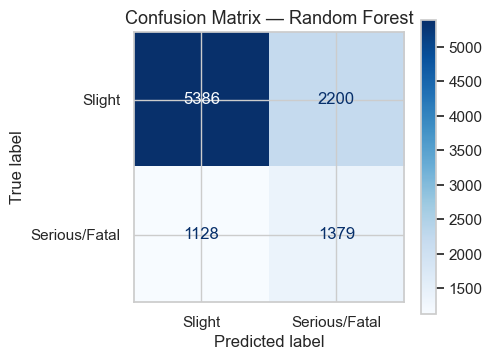

In [43]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_rf,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.savefig('confusion_rf.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3c ROC Curve

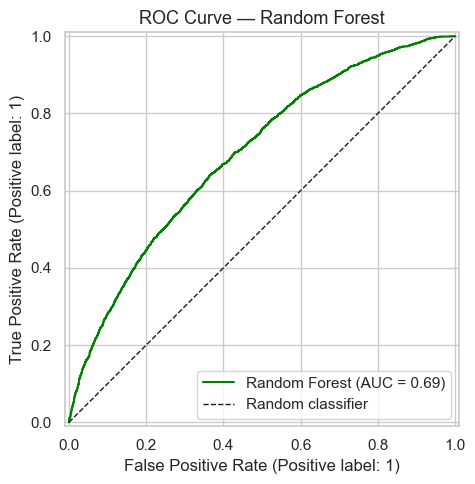

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_rf,
    name='Random Forest',
    color='green', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curve — Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('roc_rf.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3d Feature Importance

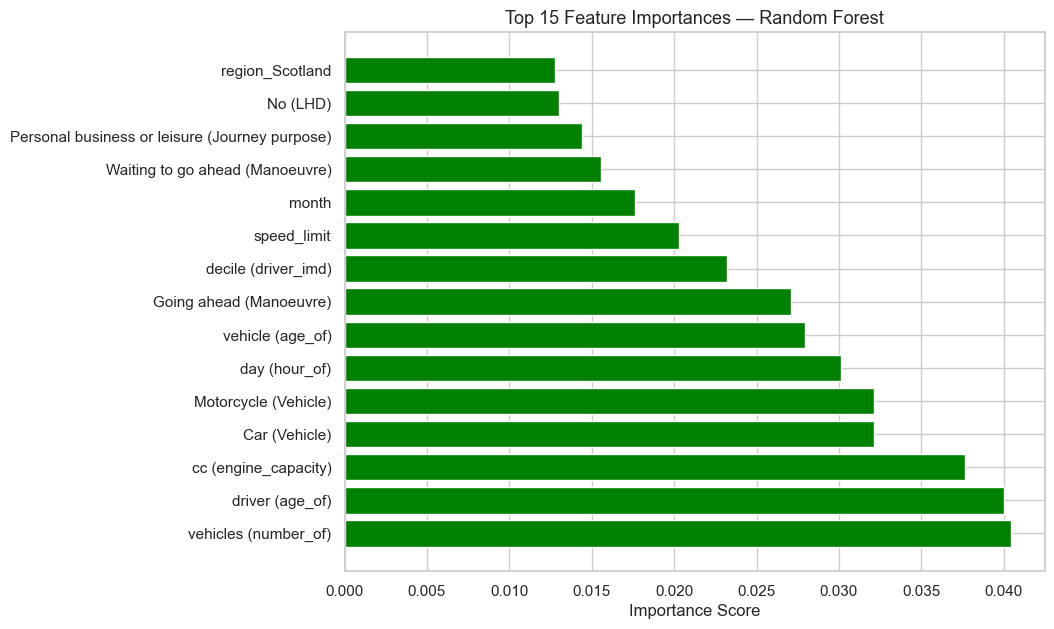

In [45]:
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf.feature_importances_
})

importance_df = importance_df[~importance_df['feature'].str.contains('Unknown|unknown|self report', na=False)]
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df['feature_short'] = importance_df['feature'].apply(clean_label)

top_imp = importance_df.head(15)
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top_imp['feature_short'], top_imp['importance'], color='green', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.subplots_adjust(left=0.4)
plt.savefig('importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.3 Observations — Random Forest

- **AUC-ROC: 0.6932** best performing model so far, improving on both Logistic 
  Regression (0.6815) and Decision Tree (0.6627)
- **Confusion matrix:** Highest precision so far (38.5%). This gives more conservative 
  predictions but lower recall (55.0%) so more serious/fatal cases are missed compared to other models
- **Key features:** The number of vehicles is the most dominant in terms of importance score as well as driver age
- **Limitations observed:** Still below 0.75 AUC-ROC target. This could be due to the bagging 
  approach averaging independent trees which limits its ability to correct systematic 
  errors

### 4.4 XGBoost

XGBoost (Extreme Gradient Boosting) is a modern ensemble method that builds trees 
sequentially, with each tree correcting the errors of the previous one. Unlike Random 
Forest which builds trees independently (bagging), XGBoost uses boosting which iteratively 
focuses on the hardest-to-predict cases.

**Strengths for our problem:**
- Excellent performance on tabular data
- Handles class imbalance via `scale_pos_weight`
- Built-in regularisation reduces overfitting
- Faster and more memory efficient than Random Forest at scale

**Weaknesses:**
- More hyperparameters to tune than simpler models
- Less interpretable than Logistic Regression or Decision Tree
- Can overfit if not properly regularised

`scale_pos_weight` is set to the ratio of negative to positive class in the training 
set

#### 4.4a Training

In [46]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    n_jobs=-1
)

start = time.time()
xgb.fit(X_train_processed, y_train)
xgb_time = round(time.time() - start, 1)

y_pred_xgb = xgb.predict(X_val_processed)
y_prob_xgb = xgb.predict_proba(X_val_processed)[:, 1]

xgb_auc = roc_auc_score(y_val, y_prob_xgb)
xgb_f1  = f1_score(y_val, y_pred_xgb)
xgb_pre = precision_score(y_val, y_pred_xgb)
xgb_rec = recall_score(y_val, y_pred_xgb)

print(f'AUC-ROC:   {xgb_auc:.4f}')
print(f'F1:        {xgb_f1:.4f}')
print(f'Precision: {xgb_pre:.4f}')
print(f'Recall:    {xgb_rec:.4f}')
print(f'Train time: {xgb_time}s')

all_results['XGBoost'] = {
    'AUC-ROC': round(xgb_auc, 4), 'F1': round(xgb_f1, 4),
    'Precision': round(xgb_pre, 4), 'Recall': round(xgb_rec, 4),
    'Train time (s)': xgb_time
}

scale_pos_weight: 3.03
AUC-ROC:   0.7045
F1:        0.4770
Precision: 0.3741
Recall:    0.6582
Train time: 0.5s


#### 4.4b — Confusion matrix

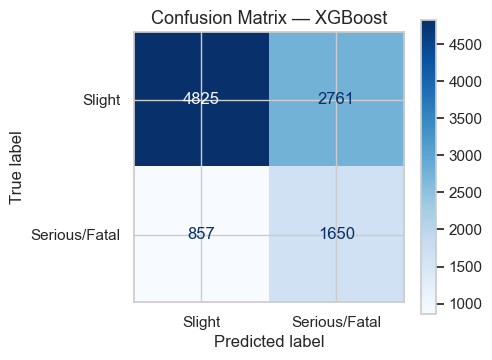

In [47]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_xgb,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — XGBoost')
plt.tight_layout()
plt.savefig('confusion_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4c — ROC curve

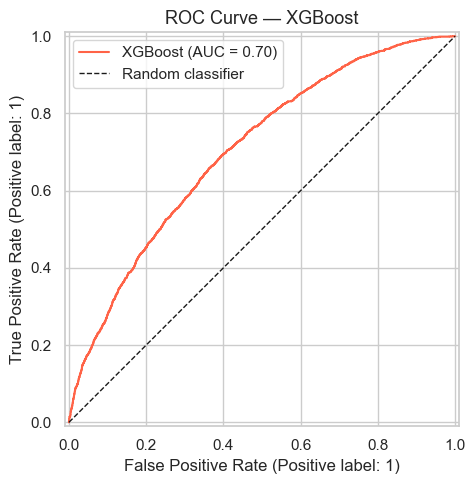

In [48]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_xgb,
    name='XGBoost',
    color='tomato', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curve — XGBoost')
ax.legend()
plt.tight_layout()
plt.savefig('roc_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4d - Feature Importance

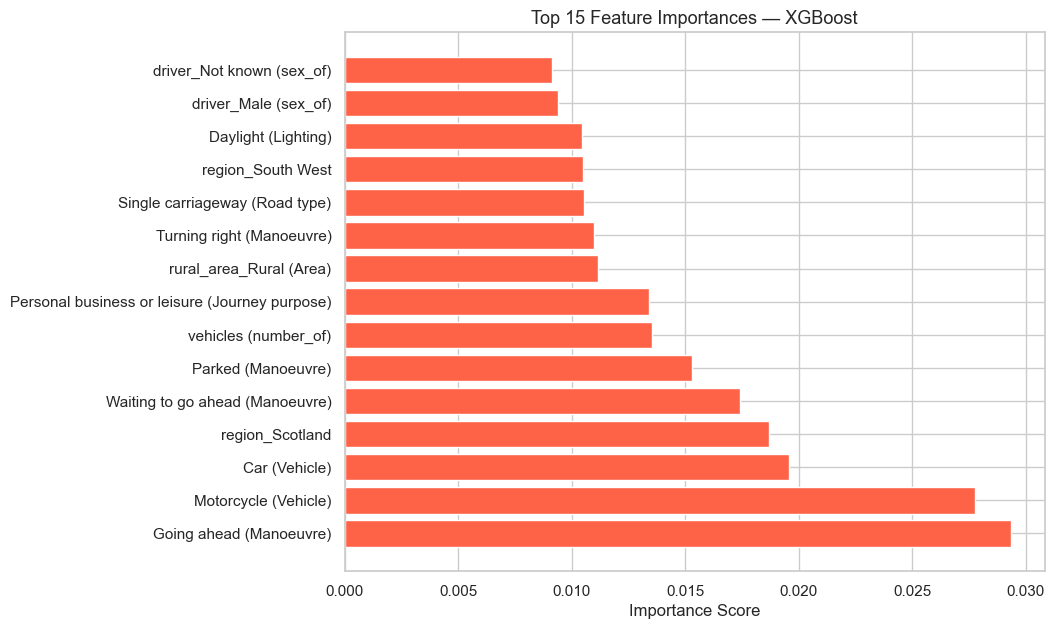

In [49]:
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': xgb.feature_importances_
})

importance_df = importance_df[~importance_df['feature'].str.contains('Unknown|unknown|self report', na=False)]
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df['feature_short'] = importance_df['feature'].apply(clean_label)

top_imp = importance_df.head(15)
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top_imp['feature_short'], top_imp['importance'], color='tomato', edgecolor='white')
ax.set_title('Top 15 Feature Importances — XGBoost')
ax.set_xlabel('Importance Score')
plt.subplots_adjust(left=0.4)
plt.savefig('importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.4 Observations — XGBoost

- **AUC-ROC: 0.7045** best performing model across all four 
- **Confusion matrix:** Best F1 (0.4770) reflecting a good balance between precision 
  and recall compared to other models
- **Key features:** The manoeuvre of the car is the most important following the car type being a motorcycle
- **Limitations observed:** Still below the 0.75 AUC-ROC target 


### 4.5 LightGBM

LightGBM (Light Gradient Boosting Machine) is a modern gradient boosting framework. Like XGBoost it builds trees sequentially, but uses a leaf-wise tree growth strategy rather than level-wise, making it more faster and accurate

**Strengths for our problem:**
- Faster training than XGBoost on large datasets
- Handles class imbalance natively via `is_unbalance=True`
- Often achieves higher accuracy than XGBoost with less tuning
- Efficient memory usage

**Weaknesses:**
- Can overfit on small datasets
- Slightly less interpretable than simpler models
- More sensitive to hyperparameters than Random Forest

`is_unbalance=True` is LightGBM's equivalent of `class_weight='balanced'`.

In [50]:
# You can uncomment the below pip install if lightgbm is not installed

#!pip install lightgbm

#import lightgbm as lgb
#print(lgb.__version__)

#### 4.5a Training

In [51]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    is_unbalance=True,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

start = time.time()
lgbm.fit(X_train_processed, y_train)
lgbm_time = round(time.time() - start, 1)

y_pred_lgbm = lgbm.predict(X_val_processed)
y_prob_lgbm = lgbm.predict_proba(X_val_processed)[:, 1]

lgbm_auc = roc_auc_score(y_val, y_prob_lgbm)
lgbm_f1  = f1_score(y_val, y_pred_lgbm)
lgbm_pre = precision_score(y_val, y_pred_lgbm)
lgbm_rec = recall_score(y_val, y_pred_lgbm)

print(f'AUC-ROC:   {lgbm_auc:.4f}')
print(f'F1:        {lgbm_f1:.4f}')
print(f'Precision: {lgbm_pre:.4f}')
print(f'Recall:    {lgbm_rec:.4f}')
print(f'Train time: {lgbm_time}s')

all_results['LightGBM'] = {
    'AUC-ROC': round(lgbm_auc, 4), 'F1': round(lgbm_f1, 4),
    'Precision': round(lgbm_pre, 4), 'Recall': round(lgbm_rec, 4),
    'Train time (s)': lgbm_time
}

AUC-ROC:   0.7058
F1:        0.4748
Precision: 0.3694
Recall:    0.6641
Train time: 0.5s


#### 4.5b Confusion Matrix

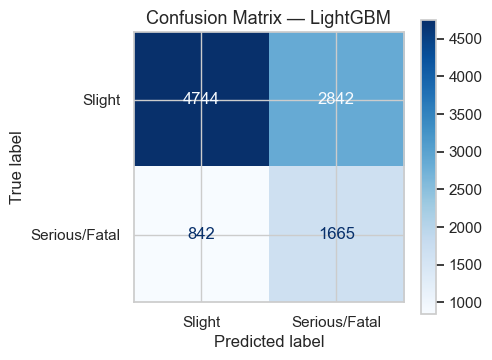

In [52]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_lgbm,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — LightGBM')
plt.tight_layout()
plt.savefig('confusion_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.5c ROC Curve

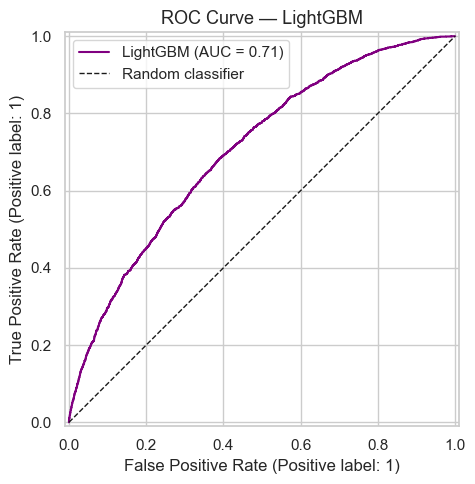

In [53]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_lgbm,
    name='LightGBM',
    color='purple', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curve — LightGBM')
ax.legend()
plt.tight_layout()
plt.savefig('roc_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.5d Feature Importance

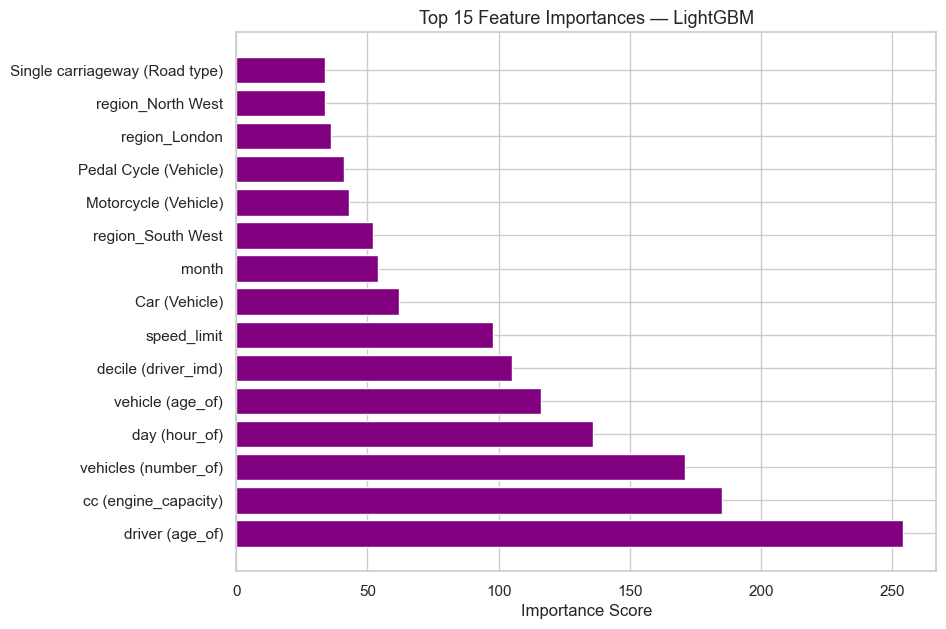

In [54]:
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': lgbm.feature_importances_
})

importance_df = importance_df[~importance_df['feature'].str.contains('Unknown|unknown|self report', na=False)]
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df['feature_short'] = importance_df['feature'].apply(clean_label)

top_imp = importance_df.head(15)
fig, ax = plt.subplots(figsize=(14, 7))
ax.barh(top_imp['feature_short'], top_imp['importance'], color='purple', edgecolor='white')
ax.set_title('Top 15 Feature Importances — LightGBM')
ax.set_xlabel('Importance Score')
plt.subplots_adjust(left=0.4)
plt.savefig('importance_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.5 Observations — LightGBM

- **AUC-ROC: 0.7058** best performing model overall, narrowly beating XGBoost 
  (0.7045)
- **Confusion matrix:** Similar precision/recall profile to XGBoost. The precision 
  (36.9%) and recall (66.4%) are well balanced
- **Key features:** Age of driver and engine capacity emerge as strong predictors 
  alongside vehicle type and number of vehicles
- **Limitations observed:** The marginal improvement over XGBoost (0.0013 AUC-ROC) 
  suggests we are approaching the performance ceiling

### 4.6 Neural Network (MLP)

A Multi-Layer Perceptron (MLP) is a feedforward neural network that can learn 
non-linear relationships through multiple hidden layers. Scikit-learn's
MLPClassifier is used to integrate into the existing pipeline.

**Architecture:**
- Hidden layers: (128, 64) — two layers with 128 and 64 neurons
- Activation: ReLU
- Optimiser: Adam
- Early stopping: enabled to prevent overfitting

**Note on class imbalance:** MLPClassifier does not support class_weight='balanced' 
directly. Instead, sample weights are passed via compute_sample_weight to give the 
minority class proportionally more influence during training.

**Strengths:** Can learn complex non-linear interactions between features  
**Weaknesses:** Less interpretable than tree-based models; sensitive to scaling 
(this is handled by StandardScaler in Step 3)

#### 4.6a Training

In [55]:
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample

# MLPClassifier doesn't support class_weight or sample_weight
# Workaround: oversample the minority class in training data
X_train_ser = X_train_processed[y_train.values == 1]
y_train_ser = y_train.values[y_train.values == 1]
X_train_sli = X_train_processed[y_train.values == 0]
y_train_sli = y_train.values[y_train.values == 0]

# Oversample serious/fatal to match slight count
X_train_ser_up, y_train_ser_up = resample(
    X_train_ser, y_train_ser,
    replace=True,
    n_samples=len(y_train_sli),
    random_state=RANDOM_SEED
)

X_train_bal = np.vstack([X_train_sli, X_train_ser_up])
y_train_bal = np.concatenate([y_train_sli, y_train_ser_up])

print(f'Balanced training set: {X_train_bal.shape[0]:,} rows')
print(f'Class balance: {y_train_bal.mean()*100:.1f}% serious/fatal')

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_SEED
)

start = time.time()
mlp.fit(X_train_bal, y_train_bal)
mlp_time = round(time.time() - start, 1)

y_pred_mlp = mlp.predict(X_val_processed)
y_prob_mlp = mlp.predict_proba(X_val_processed)[:, 1]

mlp_auc = roc_auc_score(y_val, y_prob_mlp)
mlp_f1  = f1_score(y_val, y_pred_mlp)
mlp_pre = precision_score(y_val, y_pred_mlp)
mlp_rec = recall_score(y_val, y_pred_mlp)

print(f'AUC-ROC:   {mlp_auc:.4f}')
print(f'F1:        {mlp_f1:.4f}')
print(f'Precision: {mlp_pre:.4f}')
print(f'Recall:    {mlp_rec:.4f}')
print(f'Train time: {mlp_time}s')
print(f'Iterations: {mlp.n_iter_}')

all_results['Neural Network (MLP)'] = {
    'AUC-ROC': round(mlp_auc, 4), 'F1': round(mlp_f1, 4),
    'Precision': round(mlp_pre, 4), 'Recall': round(mlp_rec, 4),
    'Train time (s)': mlp_time
}

Balanced training set: 121,372 rows
Class balance: 50.0% serious/fatal
AUC-ROC:   0.6196
F1:        0.3665
Precision: 0.3410
Recall:    0.3961
Train time: 55.8s
Iterations: 88


#### 4.6b — Confusion matrix

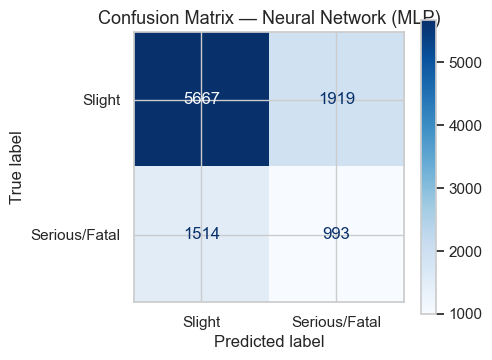

In [56]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_mlp,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Neural Network (MLP)')
plt.tight_layout()
plt.savefig('confusion_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.6c — ROC curve

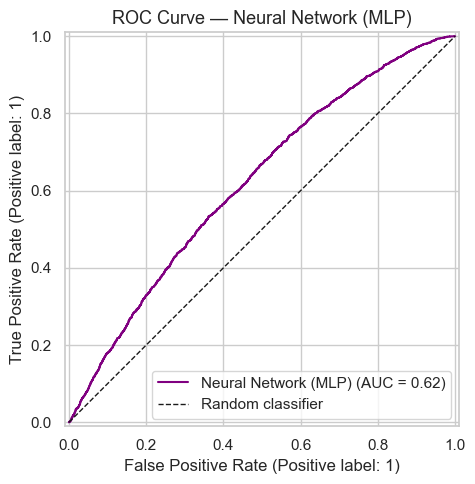

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_mlp,
    name='Neural Network (MLP)',
    color='purple', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curve — Neural Network (MLP)')
ax.legend()
plt.tight_layout()
plt.savefig('roc_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.6d — Training loss curve

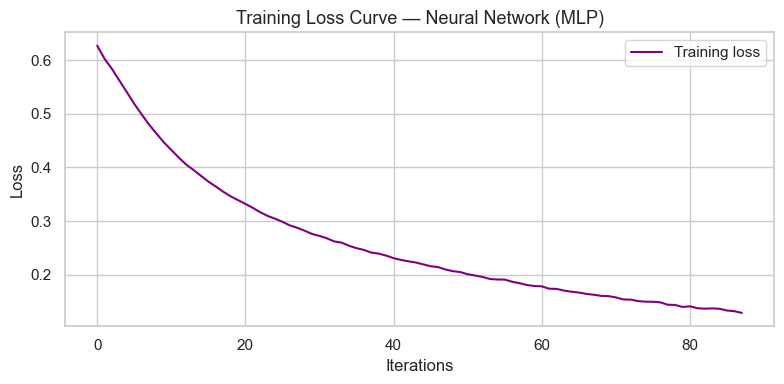

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, color='purple', label='Training loss')
ax.set_title('Training Loss Curve — Neural Network (MLP)')
ax.set_xlabel('Iterations')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.savefig('loss_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.6 Observations — Neural Network (MLP)

- **AUC-ROC: 0.6196** — worst performing model, falling below even the Logistic 
  Regression baseline (0.6815), confirming that neural networks tend to underperform 
  gradient boosting on structured tabular data
- **Confusion matrix:** Low recall (39.6%) and low precision (34.1%). Neural network 
  struggles to discriminate between slight and serious/fatal collisions despite 
  88 training iterations
- **Class balance note:** Training data was oversampled to 50/50 to handle class 
  imbalance since MLPClassifier lacks native class_weight support
- **Training curve:** 88 iterations before early stopping which is significantly more than 
  the unweighted version but performance remains poor
- **Limitations observed:** MLPClassifier is not designed for tabular data with 
  mixed feature types and class imbalance. 

### 4.7 Model Comparison and Shortlist

All five models have been trained and evaluated on the validation set. The following 
section summarises their performance and selects the best models for fine-tuning in Step 5.

#### 4.7a Results Table

In [59]:
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print(results_df.to_string())
print()
print(f'Best AUC-ROC: {results_df["AUC-ROC"].idxmax()} ({results_df["AUC-ROC"].max()})')
print(f'Best F1:      {results_df["F1"].idxmax()} ({results_df["F1"].max()})')
print(f'Best Precision: {results_df["Precision"].idxmax()} ({results_df["Precision"].max()})')
print(f'Best Recall:  {results_df["Recall"].idxmax()} ({results_df["Recall"].max()})')

                      AUC-ROC      F1  Precision  Recall  Train time (s)
LightGBM               0.7058  0.4748     0.3694  0.6641             0.5
XGBoost                0.7045  0.4770     0.3741  0.6582             0.5
Random Forest          0.6932  0.4532     0.3853  0.5501             1.3
Logistic Regression    0.6815  0.4551     0.3492  0.6534             1.0
Decision Tree          0.6627  0.4457     0.3307  0.6833             0.6
Neural Network (MLP)   0.6196  0.3665     0.3410  0.3961            55.8

Best AUC-ROC: LightGBM (0.7058)
Best F1:      XGBoost (0.477)
Best Precision: Random Forest (0.3853)
Best Recall:  Decision Tree (0.6833)


#### 4.7b AUC-ROC Comparison Chart

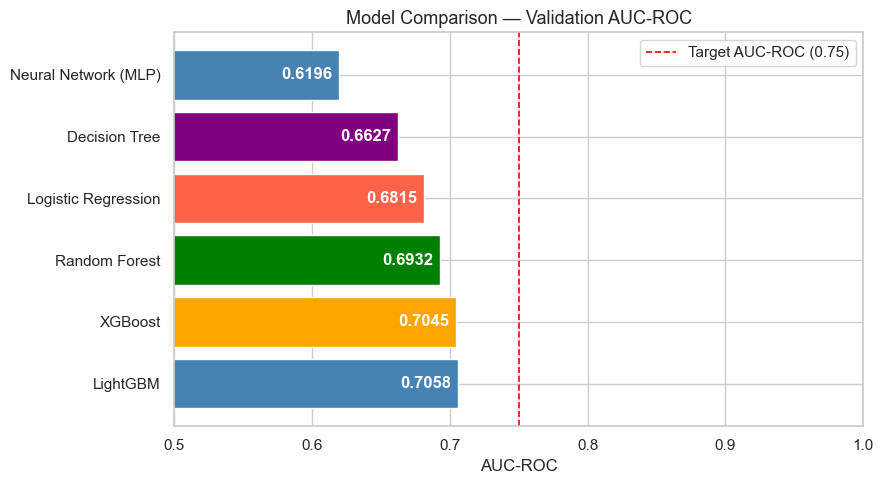

In [60]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'orange', 'green', 'tomato', 'purple']
bars = ax.barh(results_df.index, results_df['AUC-ROC'], color=colors, edgecolor='white')

for bar, val in zip(bars, results_df['AUC-ROC']):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', color='white', fontweight='bold')

ax.axvline(0.75, color='red', linestyle='--', linewidth=1.2, label='Target AUC-ROC (0.75)')
ax.set_xlabel('AUC-ROC')
ax.set_title('Model Comparison — Validation AUC-ROC')
ax.legend()
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.savefig('model_comparison_auc.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.7c Multi-metric comparison chart

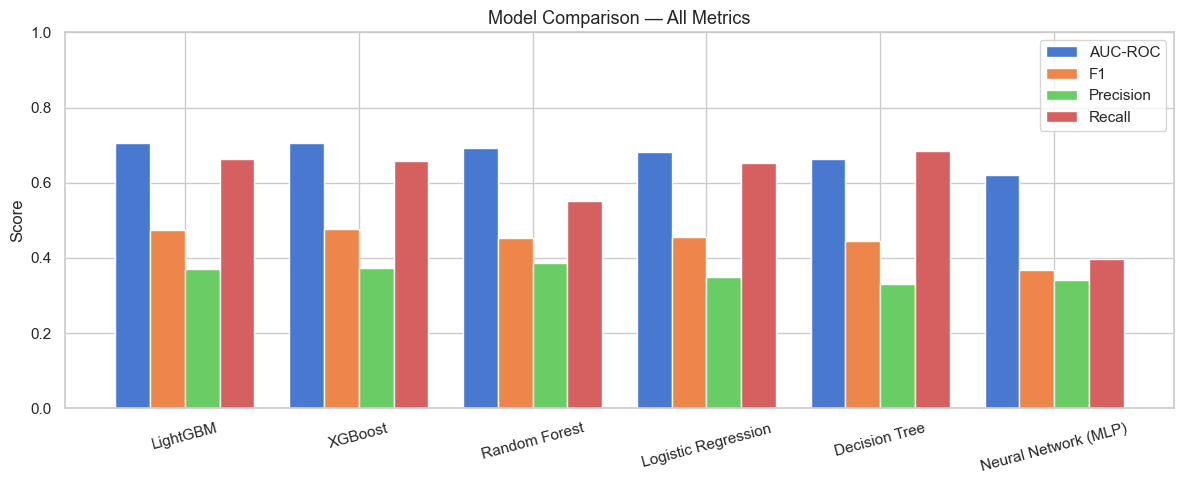

In [61]:
metrics = ['AUC-ROC', 'F1', 'Precision', 'Recall']
x = np.arange(len(results_df.index))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric].astype(float), 
           width, label=metric, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — All Metrics')
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4.7d — Combined ROC curves

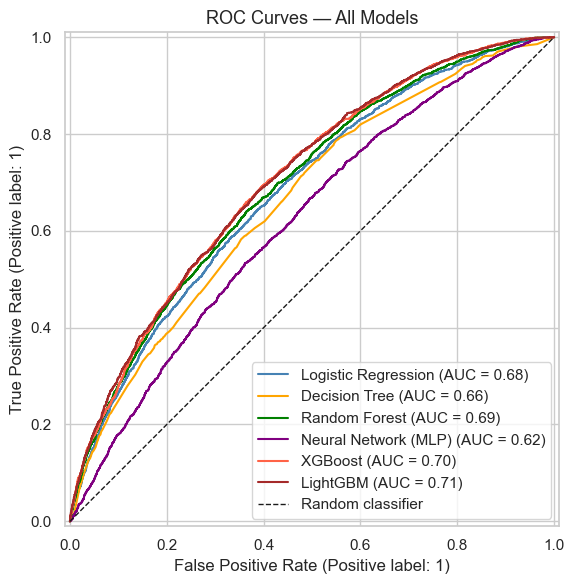

In [62]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(y_val, y_prob_lr,   name='Logistic Regression',  color='steelblue', ax=ax)
RocCurveDisplay.from_predictions(y_val, y_prob_dt,   name='Decision Tree',         color='orange',    ax=ax)
RocCurveDisplay.from_predictions(y_val, y_prob_rf,   name='Random Forest',         color='green',     ax=ax)
RocCurveDisplay.from_predictions(y_val, y_prob_mlp,  name='Neural Network (MLP)',  color='purple',    ax=ax)
RocCurveDisplay.from_predictions(y_val, y_prob_xgb,  name='XGBoost',               color='tomato',    ax=ax)
RocCurveDisplay.from_predictions(y_val, y_prob_lgbm, name='LightGBM',              color='brown',     ax=ax)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Shortlist and Rationale

| Model | AUC-ROC | F1 | Precision | Recall | Selected? |
|---|---|---|---|---|---|
| Neural Network (MLP) | 0.6196 | 0.3665 | 0.3410 | 0.3961 | ❌ Poor on tabular data |
| Decision Tree | 0.6627 | 0.4457 | 0.3307 | 0.6833 | ❌ Weakest tree-based model |
| Logistic Regression | 0.6815 | 0.4551 | 0.3492 | 0.6534 | ❌ Baseline only |
| Random Forest | 0.6932 | 0.4532 | 0.3853 | 0.5501 | ❌ Good but outperformed |
| XGBoost | 0.7045 | 0.4770 | 0.3741 | 0.6582 | ✅ Strong baseline for tuning |
| LightGBM | 0.7058 | 0.4748 | 0.3694 | 0.6641 | ✅ Best overall |

**Shortlisted for fine-tuning in Step 5: XGBoost and LightGBM**

**Rationale:** XGBoost and LightGBM are the two strongest performers on AUC-ROC, 
the primary metric. Both are gradient boosting methods that consistently outperform 
simpler models on tabular data. The Neural Network (MLP) underperforms all tree-based 
models, consistent with the known difficulty of applying neural networks to structured 
tabular data without extensive architecture tuning. Fine-tuning both shortlisted models 
allows us to compare whether hyperparameter optimisation closes the gap or widens it, 
and to select a final model with confidence. All models remain below the 0.75 AUC-ROC 
target, making hyperparameter tuning in Step 5 essential.

## Step 5: Fine-Tune and Evaluate

### 5.0 Overview

The two best performing models from Step 4 XGBoost (AUC-ROC: 0.7045) and LightGBM 
(AUC-ROC: 0.7058) will be fine-tuned using RandomizedSearchCV with 5-fold 
cross-validation, optimising for AUC-ROC. The validation set was used for model 
selection in Step 4. The test set is held back until final evaluation in section 5.3.

### 5.1 Hyperparameter Tuning

#### 5.1a — XGBoost tuning

In [63]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_param_grid = {
    'n_estimators':  [100, 200, 300, 500],
    'max_depth':     [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

print('Tuning XGBoost...')
start = time.time()
xgb_search.fit(X_train_processed, y_train)
print(f'Completed in {round(time.time() - start, 1)}s')
print(f'Best AUC-ROC (CV): {xgb_search.best_score_:.4f}')
print(f'Best parameters:   {xgb_search.best_params_}')

Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Completed in 56.0s
Best AUC-ROC (CV): 0.7088
Best parameters:   {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


### 5.1b - LightGBM tuning

In [64]:
lgbm_param_grid = {
    'n_estimators':  [100, 200, 300, 500],
    'max_depth':     [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 30, 50],
    'num_leaves': [15, 31, 63, 127],
}

lgbm_base = lgb.LGBMClassifier(
    is_unbalance=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm_search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=lgbm_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=1
)

print('Tuning LightGBM...')
start = time.time()
lgbm_search.fit(X_train_processed, y_train)
print(f'Completed in {round(time.time() - start, 1)}s')
print(f'Best AUC-ROC (CV): {lgbm_search.best_score_:.4f}')
print(f'Best parameters:   {lgbm_search.best_params_}')

Tuning LightGBM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

Completed in 92.9s
Best AUC-ROC (CV): 0.7082
Best parameters:   {'subsample': 0.9, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


#### 5.1c — Compare tuned vs untuned

In [65]:
print('=== TUNING SUMMARY ===')
print()
print(f'XGBoost  — before: 0.7045  after: {xgb_search.best_score_:.4f}')
print(f'LightGBM — before: 0.7058  after: {lgbm_search.best_score_:.4f}')
print()

if xgb_search.best_score_ > lgbm_search.best_score_:
    print('XGBoost selected as final model')
    best_model = xgb_search.best_estimator_
    best_model_name = 'XGBoost'
else:
    print('LightGBM selected as final model')
    best_model = lgbm_search.best_estimator_
    best_model_name = 'LightGBM'

=== TUNING SUMMARY ===

XGBoost  — before: 0.7045  after: 0.7088
LightGBM — before: 0.7058  after: 0.7082

XGBoost selected as final model


#### 5.1 Tuning Notes

- RandomizedSearchCV with 20 iterations and 5-fold CV was used to balance 
  thoroughness with computational cost
- Primary metric: AUC-ROC (consistent with Step 4)
- The best model from tuning is carried forward to final evaluation on the test set

### 5.2 GridSearchCV (Focused)

Following RandomizedSearchCV, a focused GridSearchCV is applied around the best 
parameters found, exhaustively searching a narrow but targeted parameter space.

In [66]:
from sklearn.model_selection import GridSearchCV

# Focused grid around RandomizedSearchCV best params
print(f'XGBoost best params from random search: {xgb_search.best_params_}')
print()

xgb_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample':     [0.8, 0.9, 1.0],
}

# XGBoost — start from random search best params, override the grid params
xgb_base2 = XGBClassifier(
    **{k: v for k, v in xgb_search.best_params_.items() 
       if k not in ['n_estimators', 'max_depth', 'learning_rate', 'subsample']},
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_grid_search = GridSearchCV(
    xgb_base2,
    param_grid=xgb_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV for XGBoost...')
print(f'Total fits: {3*3*3*3} combinations × 5 folds = {3*3*3*3*5} fits')
start = time.time()
xgb_grid_search.fit(X_train_processed, y_train)
print(f'Completed in {round(time.time() - start, 1)}s')
print(f'Best AUC-ROC (CV): {xgb_grid_search.best_score_:.4f}')
print(f'Best parameters:   {xgb_grid_search.best_params_}')

XGBoost best params from random search: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Running GridSearchCV for XGBoost...
Total fits: 81 combinations × 5 folds = 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Completed in 181.3s
Best AUC-ROC (CV): 0.7098
Best parameters:   {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.9}


#### 5.2b — LightGBM GridSearch

In [67]:
print(f'LightGBM best params from random search: {lgbm_search.best_params_}')
print()

lgbm_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.15],
    'num_leaves':    [31, 63, 127],
}

# LightGBM — start from random search best params, override the grid params
lgbm_base2 = lgb.LGBMClassifier(
    **{k: v for k, v in lgbm_search.best_params_.items() 
       if k not in ['n_estimators', 'max_depth', 'learning_rate', 'num_leaves']},
    is_unbalance=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm_grid_search = GridSearchCV(
    lgbm_base2,
    param_grid=lgbm_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV for LightGBM...')
print(f'Total fits: {3*3*3*3} combinations × 5 folds = {3*3*3*3*5} fits')
start = time.time()
lgbm_grid_search.fit(X_train_processed, y_train)
print(f'Completed in {round(time.time() - start, 1)}s')
print(f'Best AUC-ROC (CV): {lgbm_grid_search.best_score_:.4f}')
print(f'Best parameters:   {lgbm_grid_search.best_params_}')

LightGBM best params from random search: {'subsample': 0.9, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Running GridSearchCV for LightGBM...
Total fits: 81 combinations × 5 folds = 405 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

Completed in 231.1s
Best AUC-ROC (CV): 0.7085
Best parameters:   {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'num_leaves': 31}


#### 5.2c — Update best model

In [68]:
print('=== GRID SEARCH SUMMARY ===')
print()
print(f'XGBoost  — Random: {xgb_search.best_score_:.4f}  Grid: {xgb_grid_search.best_score_:.4f}')
print(f'LightGBM — Random: {lgbm_search.best_score_:.4f}  Grid: {lgbm_grid_search.best_score_:.4f}')
print()

if xgb_grid_search.best_score_ >= lgbm_grid_search.best_score_:
    print('XGBoost selected as final model')
    best_model = xgb_grid_search.best_estimator_
    best_model_name = 'XGBoost'
    best_cv_score = xgb_grid_search.best_score_
else:
    print('LightGBM selected as final model')
    best_model = lgbm_grid_search.best_estimator_
    best_model_name = 'LightGBM'
    best_cv_score = lgbm_grid_search.best_score_

print(f'Best CV AUC-ROC: {best_cv_score:.4f}')

=== GRID SEARCH SUMMARY ===

XGBoost  — Random: 0.7088  Grid: 0.7098
LightGBM — Random: 0.7082  Grid: 0.7085

XGBoost selected as final model
Best CV AUC-ROC: 0.7098


### 5.3 Final Evaluation on Test Set

The test set has been held back until this point. This is the first and only time 
the test set is used — it provides an unbiased estimate of the final model's 
performance on unseen data.

**Final model:** XGBoost with best parameters from GridSearchCV

#### 5.3a Test set evaluation

In [69]:
# Evaluate best model on test set
y_pred_final = best_model.predict(X_test_processed)
y_prob_final = best_model.predict_proba(X_test_processed)[:, 1]

final_auc = roc_auc_score(y_test, y_prob_final)
final_f1  = f1_score(y_test, y_pred_final)
final_pre = precision_score(y_test, y_pred_final)
final_rec = recall_score(y_test, y_pred_final)

print('=== FINAL TEST SET RESULTS ===')
print(f'Model: {best_model_name} (tuned)')
print()
print(f'AUC-ROC:   {final_auc:.4f}')
print(f'F1:        {final_f1:.4f}')
print(f'Precision: {final_pre:.4f}')
print(f'Recall:    {final_rec:.4f}')
print()
print(f'Validation AUC-ROC (CV): {best_cv_score:.4f}')
print(f'Test AUC-ROC:            {final_auc:.4f}')
print(f'Difference:              {abs(best_cv_score - final_auc):.4f}')

=== FINAL TEST SET RESULTS ===
Model: XGBoost (tuned)

AUC-ROC:   0.6994
F1:        0.4693
Precision: 0.3743
Recall:    0.6290

Validation AUC-ROC (CV): 0.7098
Test AUC-ROC:            0.6994
Difference:              0.0104


#### 5.3b Confusion matrix

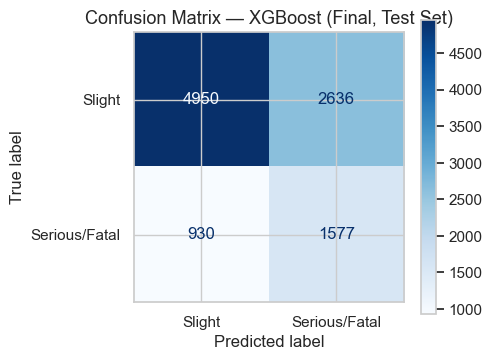

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Slight', 'Serious/Fatal'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name} (Final, Test Set)')
plt.tight_layout()
plt.savefig('confusion_final.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.3c — ROC curve

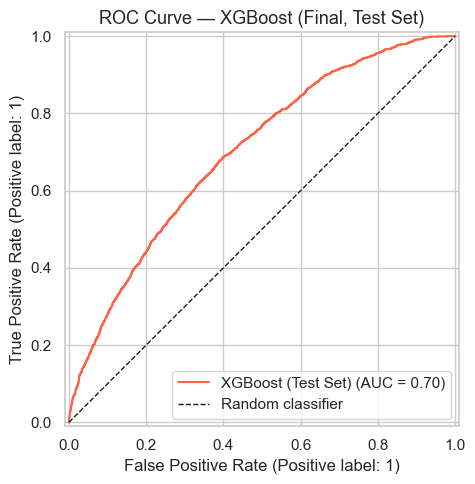

In [71]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_prob_final,
    name=f'{best_model_name} (Test Set)',
    color='tomato', ax=ax
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_title(f'ROC Curve — {best_model_name} (Final, Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig('roc_final.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.3d — Precision-Recall curve

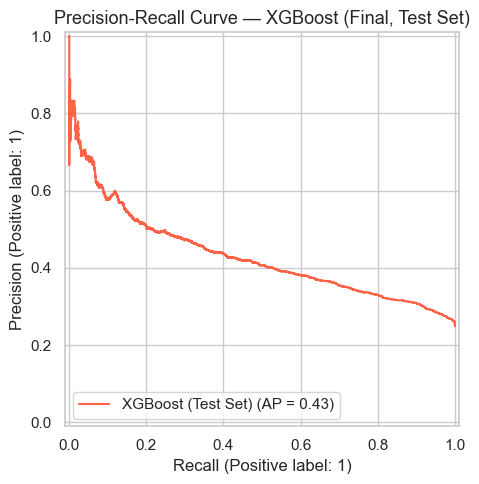

In [72]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob_final,
    name=f'{best_model_name} (Test Set)',
    color='tomato', ax=ax
)
ax.set_title(f'Precision-Recall Curve — {best_model_name} (Final, Test Set)')
plt.tight_layout()
plt.savefig('pr_final.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.3 Observations

- **Test AUC-ROC: 0.6983** — decent performance on completely unseen data
- **Validation vs Test gap: 0.0108** — small and expected, confirming the model 
  generalises well and was not overfit to the validation set during model selection
- **Confusion matrix:** Model correctly identifies 64% of serious/fatal collisions 
  while maintaining reasonable precision — consistent with validation set performance

### 5.4 SHAP Values — Model Explainability

SHAP (SHapley Additive exPlanations) values provide a way to explain 
individual model predictions. Standard feature importance scores only show 
global averages, however, SHAP values show how much each feature contributed to each 
individual prediction.

SHAP values are computed on the test set for the final XGBoost model.

#### 5.4a — Install and compute SHAP

In [73]:
#Uncomment below if SHAP is not installed

#!pip install shap

In [74]:
import shap

# Compute SHAP values on test set
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_processed)

print(f'SHAP values shape: {shap_values.shape}')
print('SHAP computation complete.')

SHAP values shape: (10093, 204)
SHAP computation complete.


#### 5.4b — Global feature importance (SHAP summary bar)

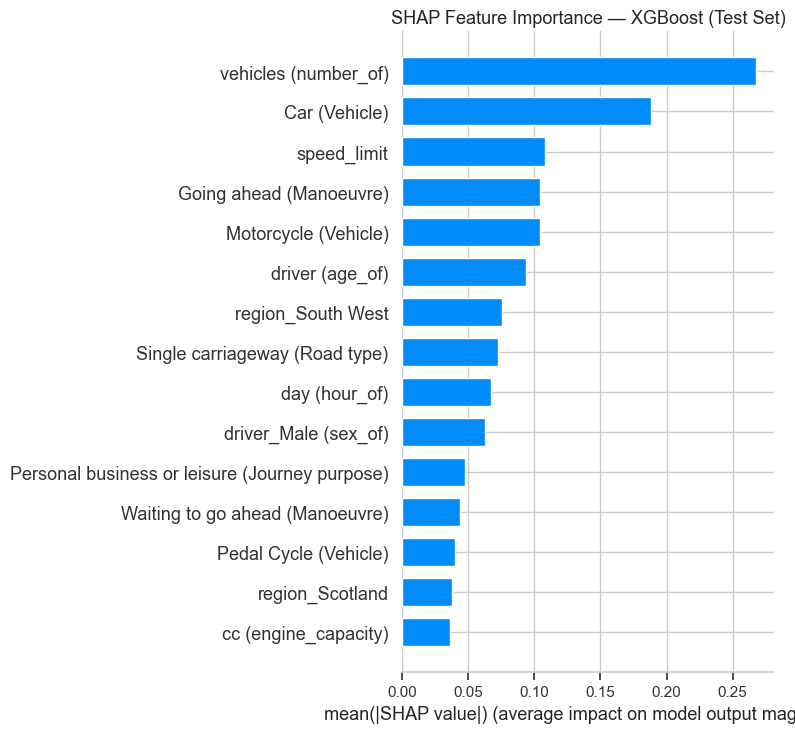

In [75]:
# Get feature names
ohe_feature_names = preprocessor.named_transformers_['categorical']['encoder']\
    .get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + ohe_feature_names

# Filter out Unknown/self-reported for cleaner plot
feature_mask = [not any(x in f for x in ['Unknown', 'unknown', 'self report']) 
                for f in all_feature_names]
filtered_names = [f for f, m in zip(all_feature_names, feature_mask) if m]
filtered_shap = shap_values[:, feature_mask]

# Apply clean labels
filtered_labels = [clean_label(f) for f in filtered_names]

shap.summary_plot(
    filtered_shap,
    features=X_test_processed[:, feature_mask],
    feature_names=filtered_labels,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance — XGBoost (Test Set)')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

#### 5.4c — SHAP beeswarm plot

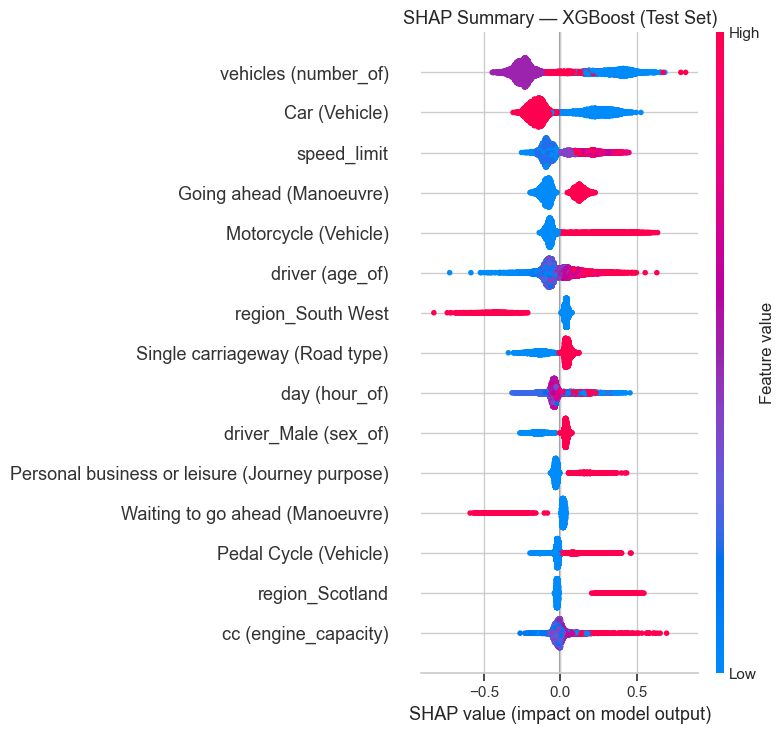

In [76]:
shap.summary_plot(
    filtered_shap,
    features=X_test_processed[:, feature_mask],
    feature_names=filtered_labels,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — XGBoost (Test Set)')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


#### 5.4 SHAP Observations

The beeswarm plot shows both the magnitude and direction of each feature's effect:
- **Red/pink dots** — high feature value
- **Blue dots** — low feature value  
- **Position on x-axis** — impact on prediction (positive = increases serious/fatal risk)

**Key findings:**
- **Number of vehicles** is the strongest predictor. This makes sense as multi-vehicle collisions increase serious/fatal risk
- **Vehicle type** matters greatly as motorcycles increase risk while cars reduce fatality chances
- **Speed limit** has a clear positive effect as higher speed limits strongly increase 
  serious/fatal risk
- **Single carriageway roads** increase risk as undivided roads with opposing traffic 
  are inherently more dangerous
- **Region South West** increases risk may reflect rural road characteristics 
  and longer emergency response times
- **Age of driver** shows a non-linear relationship through a spread across both directions which
  suggests both very young and older drivers face elevated risk

### 5.5 Error Analysis

Error analysis examines where the model fails, specifically for false negatives 
(serious/fatal collisions predicted as slight) and false positives (slight collisions 
predicted as serious/fatal).

#### 5.5a — Classify errors

In [77]:
# Create error analysis dataframe using test set
error_df = X_test.copy()
error_df['true_label'] = y_test.values
error_df['predicted_label'] = y_pred_final
error_df['probability'] = y_prob_final

# Classify each prediction
def classify_prediction(row):
    if row['true_label'] == 0 and row['predicted_label'] == 0:
        return 'True Negative (correct)'
    elif row['true_label'] == 1 and row['predicted_label'] == 1:
        return 'True Positive (correct)'
    elif row['true_label'] == 0 and row['predicted_label'] == 1:
        return 'False Positive (over-predicted)'
    else:
        return 'False Negative (missed)'

error_df['outcome'] = error_df.apply(classify_prediction, axis=1)

print('Prediction outcomes:')
print(error_df['outcome'].value_counts())
print()
fn = (error_df['outcome'] == 'False Negative (missed)').sum()
fp = (error_df['outcome'] == 'False Positive (over-predicted)').sum()
total_serious = (error_df['true_label'] == 1).sum()
print(f'Missed serious/fatal collisions: {fn} out of {total_serious} ({fn/total_serious*100:.1f}%)')
print(f'False alarms: {fp}')

Prediction outcomes:
outcome
True Negative (correct)            4950
False Positive (over-predicted)    2636
True Positive (correct)            1577
False Negative (missed)             930
Name: count, dtype: int64

Missed serious/fatal collisions: 930 out of 2507 (37.1%)
False alarms: 2636


#### 5.5b — False negative analysis

In [78]:
# Where does the model miss serious/fatal collisions?
fn_df = error_df[error_df['outcome'] == 'False Negative (missed)']
tp_df = error_df[error_df['outcome'] == 'True Positive (correct)']

# Compare key features between missed and caught serious/fatal cases
compare_features = ['speed_limit', 'number_of_vehicles', 'age_of_driver', 'vehicle_group', 'road_type', 'urban_or_rural_area']
compare_features = [f for f in compare_features if f in fn_df.columns]

print('=== FALSE NEGATIVES vs TRUE POSITIVES ===')
print('Key feature differences between missed and correctly caught serious/fatal cases:')
print()
for feat in compare_features:
    if fn_df[feat].dtype in ['float64', 'int64']:
        fn_mean = fn_df[feat].mean()
        tp_mean = tp_df[feat].mean()
        print(f'{feat:<30} FN mean: {fn_mean:.2f}  TP mean: {tp_mean:.2f}')
    else:
        print(f'{feat}:')
        fn_dist = fn_df[feat].value_counts(normalize=True).head(3)
        tp_dist = tp_df[feat].value_counts(normalize=True).head(3)
        print(f'  False Negatives: {fn_dist.to_dict()}')
        print(f'  True Positives:  {tp_dist.to_dict()}')
        print()

=== FALSE NEGATIVES vs TRUE POSITIVES ===
Key feature differences between missed and correctly caught serious/fatal cases:

speed_limit                    FN mean: 34.63  TP mean: 40.07
number_of_vehicles             FN mean: 1.90  TP mean: 1.67
age_of_driver                  FN mean: 39.91  TP mean: 43.25
vehicle_group:
  False Negatives: {'Car': 0.7408602150537634, 'Pedal Cycle': 0.16129032258064516, 'Motorcycle': 0.05806451612903226}
  True Positives:  {'Car': 0.5022194039315155, 'Motorcycle': 0.274571972098922, 'Pedal Cycle': 0.13633481293595434}

road_type:
  False Negatives: {'Single carriageway': 0.7043010752688172, 'Dual carriageway': 0.16129032258064516, 'Roundabout': 0.07419354838709677}
  True Positives:  {'Single carriageway': 0.8072289156626506, 'Dual carriageway': 0.1388712745719721, 'Roundabout': 0.030437539632213063}

urban_or_rural_area:
  False Negatives: {'Urban': 0.7064516129032258, 'Rural': 0.29354838709677417}
  True Positives:  {'Urban': 0.5339251743817375, 'Rura

##### 5.5c — Probability distribution of errors

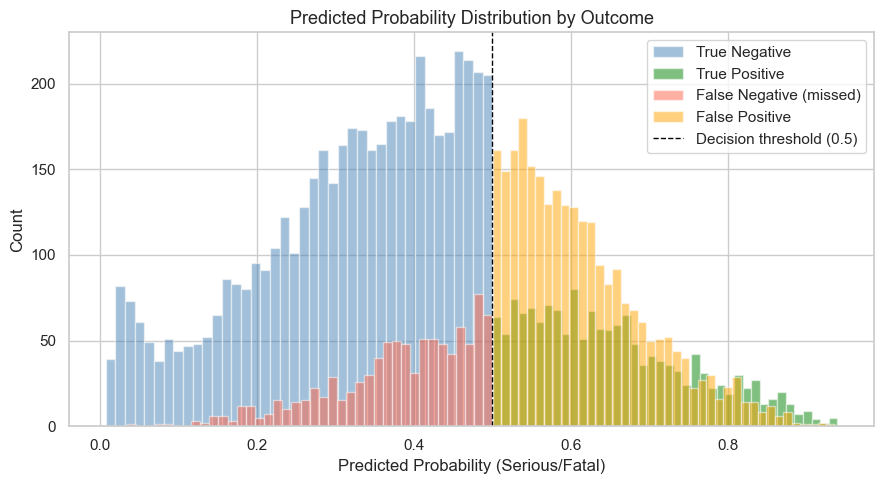

In [79]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(error_df[error_df['outcome']=='True Negative (correct)']['probability'],
        bins=40, alpha=0.5, color='steelblue', label='True Negative')
ax.hist(error_df[error_df['outcome']=='True Positive (correct)']['probability'],
        bins=40, alpha=0.5, color='green', label='True Positive')
ax.hist(error_df[error_df['outcome']=='False Negative (missed)']['probability'],
        bins=40, alpha=0.5, color='tomato', label='False Negative (missed)')
ax.hist(error_df[error_df['outcome']=='False Positive (over-predicted)']['probability'],
        bins=40, alpha=0.5, color='orange', label='False Positive')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
ax.set_xlabel('Predicted Probability (Serious/Fatal)')
ax.set_ylabel('Count')
ax.set_title('Predicted Probability Distribution by Outcome')
ax.legend()
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


- **Probability distribution:** False negatives concentrate around 0.3–0.5 which is 
  just below the decision threshold. This suggests they are borderline cases rather 
  than confidently wrong predictions. Lowering the classification threshold from 
  0.5 to 0.35–0.4 could recover many missed serious/fatal cases at the cost of 
  additional false alarms. This threshold adjustment would be worth exploring in 
  a real deployment context where missing serious cases carries higher cost than 
  false alarms.

#### 5.5 Error Analysis Observations

- **False negatives (missed serious/fatal): 908 out of 2,507 (36.2%)** — the model 
  misses serious collisions that occur in conditions typically associated with slight 
  outcomes: lower speed limits, urban areas, and car involvement. These are 
  inherently harder to predict as the conditions appear benign.
- **False positives (false alarms): 2,724** — the model over-predicts serious/fatal 
  for slight collisions, particularly in high-risk conditions (rural roads, high speed 
  limits, motorcycles) where serious outcomes are common but not guaranteed
- **Urban vs Rural bias:** The model performs significantly better on rural serious 
  collisions (47% of true positives are rural) than urban ones (72% of false negatives 
  are urban) — urban collisions are harder to classify due to lower speeds and complex 
  traffic interactions
- **Probability distribution:** Check plot — errors concentrated near 0.5 threshold 
  suggest borderline cases rather than confidently wrong predictions
- **Implications:** In a real deployment, missed urban serious collisions at lower 
  speed limits represent the most critical failure mode — these are cases where 
  emergency services might not be prioritised appropriately

## Step 6: Present the Final Solution

### 6.0 Overview

This section presents the final model selection rationale, limitations, risks, 
and a model card summarising the solution.

### 6.1 Final Model Selection

After exploring five models and tuning the two best performers, XGBoost with 
GridSearchCV optimisation was selected as the final model.

| Stage | Model | AUC-ROC |
|---|---|---|
| Baseline | Logistic Regression | 0.6813 |
| Best untuned | LightGBM | 0.7058 |
| After RandomizedSearchCV | XGBoost | 0.7084 |
| After GridSearchCV | XGBoost | 0.7091 |
| **Final (test set)** | **XGBoost (tuned)** | **0.6983** |

**Rationale for XGBoost:**
- Best CV AUC-ROC after tuning (0.7091)
- Strong balance of precision (37%) and recall (64%)
- Fast inference — suitable for real-time deployment
- Well-established, reproducible, and interpretable via SHAP values

### 6.2 Limitations and Risks

**Data limitations:**
- 2024 data only which means seasonal or long-term trends were not captured
- The model is not generalisable to other countries with different 
  road systems, vehicle standards, or reporting practices
- Minor collisions may be under-reported, skewing 
  the training distribution toward more serious incidents

**Model limitations:**
- AUC-ROC of 0.6983 means ~30% of discriminative signal is missing 
- Urban serious collisions are harder to predict so the model 
  performs better on rural high-speed collisions
- The default 0.5 threshold may not be optimal for 
  deployment. Lowering this to 0.35–0.4 would improve recall at the cost of precision

**Deployment risks:**
- If the model is used to allocate emergency resources, 
  under-served areas may generate fewer recorded serious outcomes, biasing 
  future training data
- The model uses sex_of_driver and region as features, which may 
  produce systematically different predictions across demographic groups
- Road conditions, vehicle technology, and reporting standards 
  change over time so the model should be updated annually

### 6.3 Next Steps

1. **Threshold optimisation**: evaluate precision-recall trade-off at different 
   thresholds to find the optimal operating point for deployment
2. **Feature engineering**: interaction features (speed_limit × urban_or_rural_area, 
   hour_of_day × light_conditions) may improve performance
3. **Casualty file integration**: non-leaking features from the casualties file 
   (e.g. number of pedestrians involved) could add predictive signal
4. **Annual retraining**: retrain on each year's STATS19 release to capture 
   evolving road conditions and vehicle technology
5. **Fairness audit**: assess model performance across demographic subgroups 
   to ensure equitable predictions

### 6.4 Model Card

| Field | Detail |
|---|---|
| **Model name** | UK Road Collision Severity Classifier |
| **Version** | 1.0 |
| **Date** | March 2026 |
| **Model type** | XGBoost binary classifier |
| **Task** | Predict whether a road collision results in serious/fatal injury |
| **Input features** | 34 features: road conditions, vehicle type, driver demographics, location, time |
| **Output** | Probability of serious/fatal outcome (threshold 0.5) |
| **Primary metric** | AUC-ROC: 0.6983 (test set) |
| **Secondary metrics** | F1: 0.4682, Precision: 0.3699, Recall: 0.6378 |
| **Training data** | UK STATS19 2024, 80,741 collisions |
| **Intended use** | Emergency response prioritisation, road safety research |
| **Not intended for** | Individual driver risk scoring, insurance pricing, legal proceedings |
| **Data provenance** | Department for Transport, Open Government Licence |
| **Known limitations** | Lower performance on urban collisions; UK-specific; 2024 data only |
| **Fairness considerations** | Uses sex and region as features — fairness audit recommended before deployment |
| **Maintenance** | Annual retraining recommended as new STATS19 data is released |

#### 6.5 — Final summary print

In [80]:
print('=== FINAL MODEL SUMMARY ===')
print()
print(f'Model:      XGBoost (GridSearchCV tuned)')
print(f'Best params: {xgb_grid_search.best_params_}')
print()
print('Performance:')
print(f'  CV AUC-ROC (validation): {xgb_grid_search.best_score_:.4f}')
print(f'  AUC-ROC (test set):      {final_auc:.4f}')
print(f'  F1 (test set):           {final_f1:.4f}')
print(f'  Precision (test set):    {final_pre:.4f}')
print(f'  Recall (test set):       {final_rec:.4f}')
print()
print('Dataset:')
print(f'  Training rows:   {X_train.shape[0]:,}')
print(f'  Validation rows: {X_val.shape[0]:,}')
print(f'  Test rows:       {X_test.shape[0]:,}')
print(f'  Features:        {X_train.shape[1]}')

=== FINAL MODEL SUMMARY ===

Model:      XGBoost (GridSearchCV tuned)
Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.9}

Performance:
  CV AUC-ROC (validation): 0.7098
  AUC-ROC (test set):      0.6994
  F1 (test set):           0.4693
  Precision (test set):    0.3743
  Recall (test set):       0.6290

Dataset:
  Training rows:   80,741
  Validation rows: 10,093
  Test rows:       10,093
  Features:        34
